"""Inverse_500_nu_data

# Viscous Burgers Equation (Forward mode auto diff)

## Maping viscosity space to the solution space

$$ \frac{ds}{dt} + s \frac{ds}{dx} = \nu \frac{d^2s}{dx^2}$$

$$ s(x,0) = u(x), x \in (0,1),$$

$$ s(0,t) = s(1,t), $$

$$ \frac{ds(0,t)}{dx} = \frac{ds(1,t)}{dx},$$
"""

In [1]:
from flax import linen as nn
from typing import Sequence, Tuple
import jax
import jax.numpy as jnp
from torch.utils import data
from functools import partial
import time
import optax
import scipy.io
import os
import argparse
import shutil
import pandas as pd
from jax import jvp
import pickle
from sklearn import metrics
from termcolor import colored
import random
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib import rc
import seaborn as sns
# import matplotlib.pylab as plt
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
# rc('text', usetex=True)

In [2]:
## All inputs

path = ('/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Burgers/Burgers_500_nu_20_ic.mat')  # Please use the matlab script to generate data

n_train = 8500
p_data_train = 300
p_res_train = 2500
batch_size = 3500
n_test = 101
n_sensors = p_data_train #101*101
branch_layers = [64, 64, 64]
branch_nu_layers = [64, 64, 64]
branch_input_features = 1
trunk_layers = [64, 64, 64]
trunk_input_features = 2
hidden_dim = 100
hidden_dim_nu = 2
p_test = 101
result_dir = './'
epochs = 10000
vis_iter = 1000
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

data_ref = scipy.io.loadmat(path)
u_sol_train = jnp.array(data_ref['output_train_u'])

ic_and_nu_train = jnp.array(data_ref['input_train_u0_nu'])

nu_train = ic_and_nu_train[:,-1]
# nu_train = ic_and_nu_train[:,-1]

u_sol_test = jnp.array(data_ref['output_test_u'])

ic_and_nu_test = jnp.array(data_ref['input_test_u0_nu'])
nu_test = ic_and_nu_test[:,-1]
# nu_test = ic_and_nu_test[:,-1]

print("output_train: ", str(u_sol_train.shape))   # (n_train, nt, nx)
print("nu_train: ", str(nu_train.shape))  # (n_train,)
print("output_test: ", str(u_sol_test.shape))  # (n_test, nt, nx)
print("nu_test: ", str(nu_test.shape)) # (n_test,)

output_train:  (8500, 101, 101)
nu_train:  (8500,)
output_test:  (1500, 101, 101)
nu_test:  (1500,)


(101, 101)


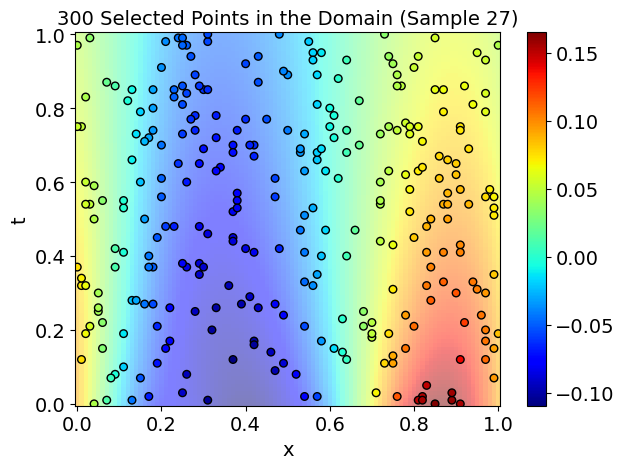

In [3]:
def extract_points(data, num_points=300):
    seed = 0
    key = jax.random.PRNGKey(seed)
    samples, ntt, nxx = data.shape
    flattened_data = data.reshape(samples, ntt * nxx)
    random_indices = jax.random.choice(key, ntt * nxx, shape=(num_points,), replace=False)
    t_indices = random_indices // ntt
    x_indices = random_indices % nxx
    t = t_indices / (ntt - 1)
    x = x_indices / (nxx - 1)

    # Create y array with (t, x) coordinates
    location = jnp.stack([t, x], axis=-1)

    # Create a grid representing the original domain
    tt = np.linspace(0, 1, ntt)
    xx = np.linspace(0, 1, nxx)
    XX, TT = jnp.meshgrid(xx, tt, indexing='ij')

    y_test = jnp.stack([TT.flatten(), XX.flatten()], axis=-1)

    # Sample s values from u_data
    extracted_data = data[:,t_indices, x_indices]

    return extracted_data, location, y_test

# Extract 300 points from each sample
data_output, location_test, y_test = extract_points(u_sol_test, p_data_train)

# Choose a sample to plot (e.g., the first sample)
sample_index = 27

# Create the plot
plt.figure()

# Create a grid representing the original domain
t = np.linspace(0, 1, 101)
x = np.linspace(0, 1, 101)
X, T = jnp.meshgrid(x, t, indexing='ij')

print(u_sol_test[sample_index].shape)
# Plot the full domain as a light background
plt.pcolormesh(X, T, u_sol_test[sample_index,:,:].T, cmap='jet', alpha=0.5)

selected_values = data_output[sample_index]

# Plot the selected points
scatter = plt.scatter(location_test[:,1], location_test[:,0], c=selected_values, cmap='jet', s=30, edgecolor='black')

cbar = plt.colorbar(scatter)
cbar.ax.tick_params(labelsize=14)
plt.title(f'{p_data_train} Selected Points in the Domain (Sample {sample_index})', fontsize=14)
plt.xlabel('x', fontsize=14)
plt.ylabel('t', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig('Data_u_300.png')
plt.show()

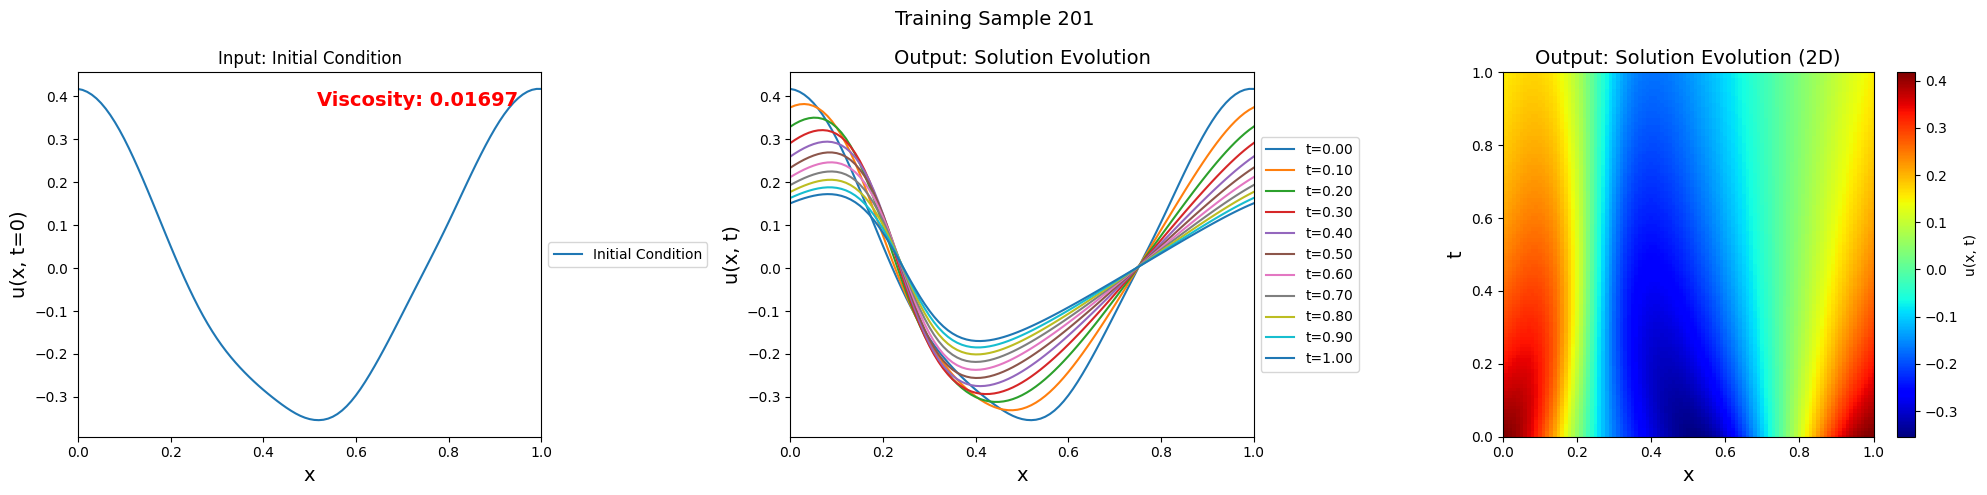

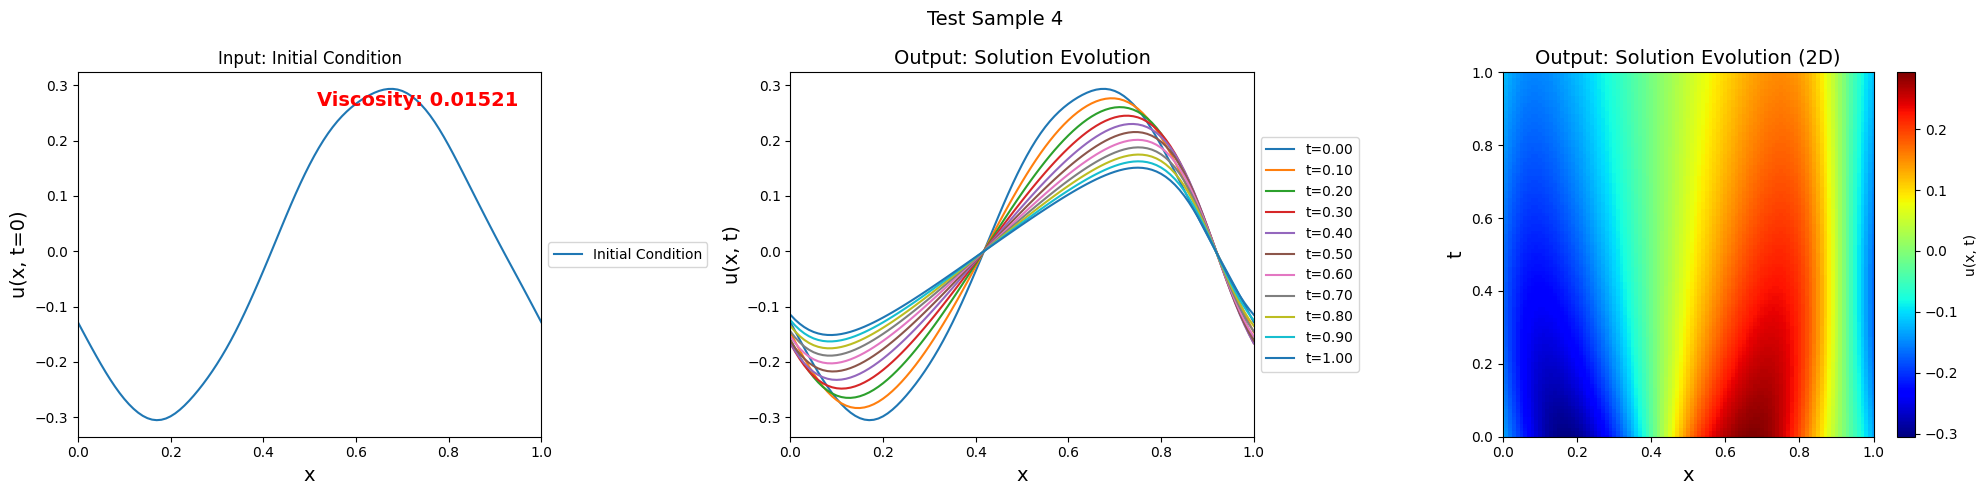

In [4]:
# Function to plot input and output for a single sample
def plot_sample(ic_and_nu, u_sol, sample_index, title):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'{title} {sample_index}', fontsize=14)

    # Create x and t arrays for the physical domain
    x = np.linspace(0, 1, ic_and_nu.shape[1] - 1)
    t = np.linspace(0, 1, u_sol.shape[1])

    XX, TT = jnp.meshgrid(x, t, indexing='ij')

    # Plot input
    ax1.plot(x, ic_and_nu[sample_index, :-1], label='Initial Condition')
    ax1.set_title('Input: Initial Condition')
    ax1.set_xlabel('x', fontsize=14)
    ax1.set_ylabel('u(x, t=0)', fontsize=14)
    ax1.set_xlim(0, 1)
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Display viscosity as text
    viscosity = ic_and_nu[sample_index, -1]
    ax1.text(0.95, 0.95, f'Viscosity: {viscosity:.5f}',
             verticalalignment='top', horizontalalignment='right',
             transform=ax1.transAxes, color='red', fontweight='bold', fontsize=14)

    # Plot output as line plots
    for i in range(0, u_sol.shape[1], 10):  # Plot every 10th time step
        ax2.plot(x, u_sol[sample_index, i, :], label=f't={t[i]:.2f}')
    ax2.set_title('Output: Solution Evolution', fontsize=14)
    ax2.set_xlabel('x', fontsize=14)
    ax2.set_ylabel('u(x, t)', fontsize=14)
    ax2.set_xlim(0, 1)
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Plot output as pcolor (flipped)
    im = ax3.pcolormesh(XX, TT, u_sol[sample_index, :, :].T, cmap='jet', shading='auto')
    ax3.set_title('Output: Solution Evolution (2D)', fontsize=14)
    ax3.set_xlabel('x', fontsize=14)
    ax3.set_ylabel('t', fontsize=14)
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    fig.colorbar(im, ax=ax3, label='u(x, t)')

    plt.tight_layout()
    plt.savefig('train_and_test_sample.png')
    plt.show()

# Plot a sample from the training set
train_sample_index = 201  # You can change this to view different samples
plot_sample(ic_and_nu_train, u_sol_train, train_sample_index, "Training Sample")

# Plot a sample from the test set
test_sample_index = 4  # You can change this to view different samples
plot_sample(ic_and_nu_test, u_sol_test, test_sample_index, "Test Sample")

In [5]:
# Data Generator
class DataGenerator(data.Dataset):
    def __init__(self, u, y, s, nu, ics, batch_size, gen_key):
        self.u = u
        self.y = y
        self.s = s
        self.nu = nu
        self.ics = ics
        self.N = nu.shape[0]
        self.batch_size = batch_size
        self.key = gen_key

    def __getitem__(self, index):
        """Generate one batch of data"""
        self.key, subkey = jax.random.split(self.key)
        inputs, outputs, nu, ics = self.__data_generation(subkey)
        return inputs, outputs, nu, ics

    @partial(jax.jit, static_argnums=(0,))
    def __data_generation(self, key_i):
        """Generates data containing batch_size samples"""
        idx = jax.random.choice(key_i, self.N, (self.batch_size,), replace=False)
        s = self.s[idx, :]
        y = self.y[:, :]
        u = self.u[idx, :]
        nu = self.nu[idx]
        ics = self.ics[idx]
        # Construct batch
        inputs = (u, y)
        outputs = s
        return inputs, outputs, nu, ics

In [6]:
"""# Data generation for each samples"""

def generate_random_data_points(nu_train_i, u_sol_train_i, key, num_points=300):
    
    # Generate random indices for sampling points
    num_t, num_x = u_sol_train_i.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(num_points,), replace=False)
    
    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_x
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)
    
    # Create y array with (t, x) coordinates
    y = jnp.stack([t, x], axis=-1)
    
    # Sample s values from u_data
    u = u_sol_train_i[t_indices, x_indices]
    
    # s = u_sol_train_i
    
    return u, y, u, nu_train_i

def generate_one_res_training_data(nu_train_i, u_sol_train_i, key, num_points=300, p=2500):

    num_t, num_x = u_sol_train_i.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(num_points,), replace=False)

    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_t
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)

    # Create y array with (t, x) coordinates
    p_grid = int(jnp.sqrt(p))  # sqrt to get square grid

    t_res_i = jax.random.uniform(key, shape=(p_grid,), minval=0, maxval=1)
    t_res_i = jnp.sort(t_res_i)  # Sort to maintain increasing order
    x_res_i = jax.random.uniform(key, shape=(p_grid,), minval=0, maxval=1)
    x_res_i = jnp.sort(x_res_i)  # Sort to maintain increasing order
    x_res, t_res = jnp.meshgrid(x_res_i, t_res_i, indexing='ij')

    y = jnp.stack([t_res.flatten(), x_res.flatten()], axis=-1)  # Shape: (p, 2)

    # Sample s values from u_data
    u = u_sol_train_i[t_indices, x_indices]

    s = u_sol_train_i

    return u, y, s, nu_train_i

In [7]:
# Create test data
seed = 0
key = jax.random.PRNGKey(seed)
keys = jax.random.split(key, 6)

# known u data
u_data_train, y_data_train, s_data_train, nu_data_train = (jax.vmap(generate_random_data_points,
                                                     in_axes=(0, 0, None, None))
                                            (nu_train, u_sol_train, key, p_data_train))

print("u_data_train: ", str(u_data_train.shape))  # Expected: (N_train, 300)
print("s_data_train: ", str(s_data_train.shape))  # Expected: (N_train, 101, 101)
print("y_data_train: ", str(y_data_train.shape))  # Expected: (N_train, 300, 2)
print("nu_data_train: ", str(nu_data_train.shape))  # Expected: (N_train,)

# Residual data
# key_res = jax.random.split(keys[0], n_train)
u_res_train, y_res_train, s_res_train, nu_res_train = (jax.vmap(generate_one_res_training_data,
                                                 in_axes=(0, 0, None, None, None))
                                         (nu_train, u_sol_train, key, p_data_train, p_res_train))

print("u_res_train: ", str(u_res_train.shape)) # Expected: (N_train, 300)
print("s_res_train: ", str(s_res_train.shape))  # Expected: (N_train, 101, 101)
print("y_res_train: ", str(y_res_train.shape)) # Expected: (N_train, 2500, 2)
print("nu_res_train: ", str(nu_res_train.shape)) # Expected: (N_train, )



# Create data generators
data_dataset = DataGenerator(u_data_train, y_data_train, s_data_train, nu_data_train, ic_and_nu_train[:, :-1], batch_size, keys[3])
res_dataset = DataGenerator(u_res_train, y_res_train, s_res_train, nu_res_train, ic_and_nu_train[:, :-1], batch_size, keys[2])


u_data_train:  (8500, 300)
s_data_train:  (8500, 300)
y_data_train:  (8500, 300, 2)
nu_data_train:  (8500,)
u_res_train:  (8500, 300)
s_res_train:  (8500, 101, 101)
y_res_train:  (8500, 2500, 2)
nu_res_train:  (8500,)


In [8]:
# DeepONet class

class DeepONet(nn.Module):
    branch_layers: Sequence[int]
    trunk_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, branch_x, trunk_x):

        init = nn.initializers.glorot_normal()

        if branch_x.ndim == 1:
            branch_x = jnp.expand_dims(branch_x, axis=-1)

#         print("branch_x_in: ", str(branch_x.shape))
        # Branch network [batch_size, 1]
        for i, fs in enumerate(self.branch_layers[:-1]):
            branch_x = nn.Dense(fs, kernel_init=init, name=f"branch_{i}")(branch_x)
            branch_x = nn.activation.tanh(branch_x)
        branch_x = nn.Dense(self.branch_layers[-1], name=f"branch_{i+1}", kernel_init=init)(branch_x)
        #[batch_size, p]
#         print("branch_x_out: ", str(branch_x.shape))

        # Trunk network
        # [x_num, 2]
        # Ensure trunk_x has at least 2 dimensions
        if trunk_x.ndim == 1:
            trunk_x = jnp.expand_dims(trunk_x, axis=0)

#         print("trunk_x_in: ", str(trunk_x.shape))

        for i, fs in enumerate(self.trunk_layers):
            trunk_x = nn.Dense(fs, kernel_init=init, name=f"trunk_{i}")(trunk_x)
            trunk_x = nn.activation.tanh(trunk_x)

#         print("trunk_x_out: ", str(trunk_x.shape))

         # [x_num, p]

        # Compute the final output
        # Input shapes:
        # branch: [batch_size, p]
        # trunk: [x_num, p]
        # output: [batch_size, x_num]
        result = jnp.einsum('ij,kj->ik', branch_x, trunk_x)

        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        result += bias

        return result


In [9]:
# NuNet class

class MLP_nu(nn.Module):
    h_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, x, training=False):
        init = nn.initializers.glorot_normal()
        # print(finput shape: {x.shape}")  # Debugging line
        for i, features in enumerate(self.h_layers):
            x = nn.Dense(features, kernel_init=init)(x)
            x = nn.silu(x)
        
        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        x += bias
        return x
        # return x
        

In [10]:
"""# Helper functions"""

@partial(jax.jit)
def mse(y_true, y_pred):
    return jnp.mean(jnp.square(y_true - y_pred))

@partial(jax.jit)
def mse_single(y_pred):
    return jnp.mean(jnp.square(y_pred))

@partial(jax.jit, static_argnums=(0,))
def apply_net(model_fn, params, branch_input, *trunk_in):
    # Define forward pass for normal DeepOnet that takes series of trunk inputs and stacks them
    if len(trunk_in) == 1:
        trunk_input = trunk_in[0]
    else:
        trunk_input = jnp.stack(trunk_in, axis=-1)
    out = model_fn(params, branch_input, trunk_input)

    # Reshape to vector for single output for easier gradient computation
    # TODO: Adapt / Check squeeze
    if out.shape[1]==1:
        out = jnp.squeeze(out, axis=1)
    return out

@partial(jax.jit, static_argnums=(0,))
def apply_net_nu(model_fn_nu, params_nu, branch_input_data):
    out = model_fn_nu(params_nu, branch_input_data)

    # TODO: Adapt / Check squeeze
    if out.shape[0]==1:
        out = jnp.squeeze(out, axis=0)
    return out


@partial(jax.jit, static_argnums=(0, 1, 2, 3))
def step(optimizer, loss_fn, model_fn_nu, model_fn, opt_state, params_step, res_batch, data_batch, key):
    loss, gradient = jax.value_and_grad(loss_fn, argnums=2)(model_fn_nu, model_fn, params_step, res_batch, data_batch, key)
    updates, opt_state = optimizer.update(gradient, opt_state)
    params_step = optax.apply_updates(params_step, updates)

    return loss, params_step, opt_state

In [11]:
"""# set the model pretrained model"""

# Initialize model and params
# make sure trunk_layers and branch_layers are lists
trunk_layers = [trunk_layers] if isinstance(trunk_layers, int) else trunk_layers

branch_layers = [branch_layers] if isinstance(branch_layers, int) else branch_layers

# add output features to trunk and branch layers
trunk_layers = trunk_layers + [hidden_dim]
branch_layers = branch_layers + [hidden_dim]

# Convert list to tuples
trunk_layers = tuple(trunk_layers)
branch_layers = tuple(branch_layers)

num_outputs = 1
model = DeepONet(branch_layers, trunk_layers, num_outputs)

# model function
model_fn = jax.jit(model.apply)

In [12]:
"""# model save function"""

def save_model_params(params, result_dir, filename='model_params.pkl'):
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)

    save_path = os.path.join(result_dir, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

def load_model_params(result_dir):
    load_path = os.path.join(result_dir)
    with open(load_path, 'rb') as f:
        params = pickle.load(f)
    return params

save = True
params_loaded = load_model_params('/home/droysar1/scr4_sgoswam4/Dibakar/INV_DON/Burgers_dist/results_burgers_0/model_params_best.pkl')

print("Loaded best model parameters")

Loaded best model parameters


Visualizing test sample at index 0


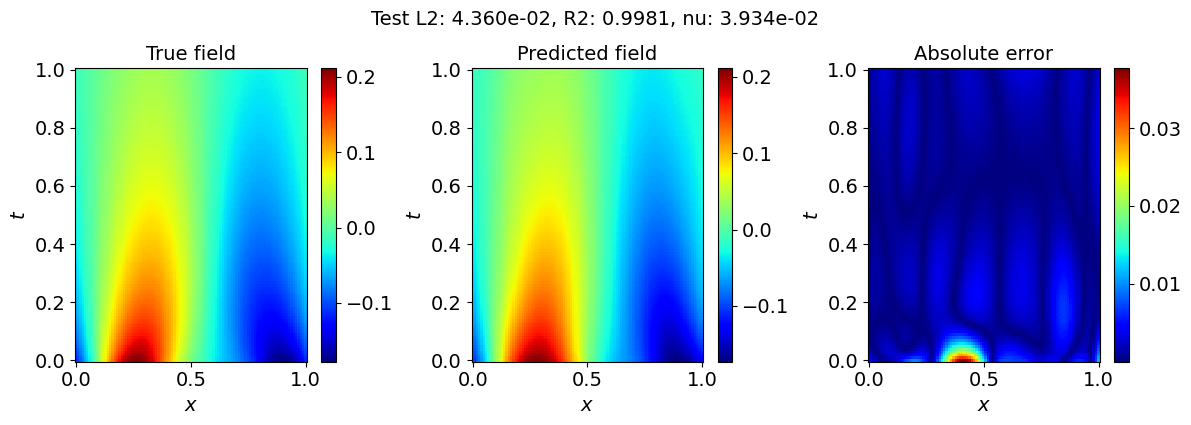

######################################################################################################################################################################################################################################
Visualizing test sample at index 100


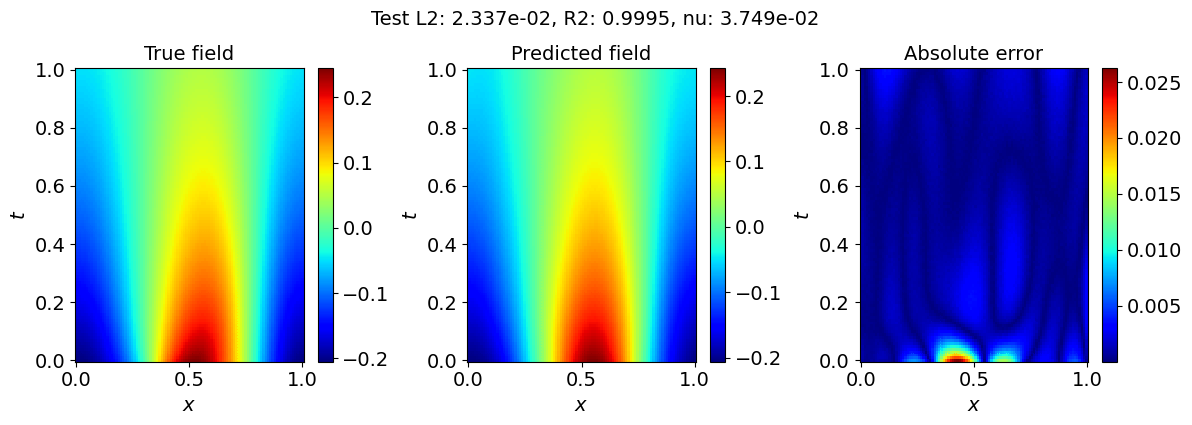

######################################################################################################################################################################################################################################
Visualizing test sample at index 200


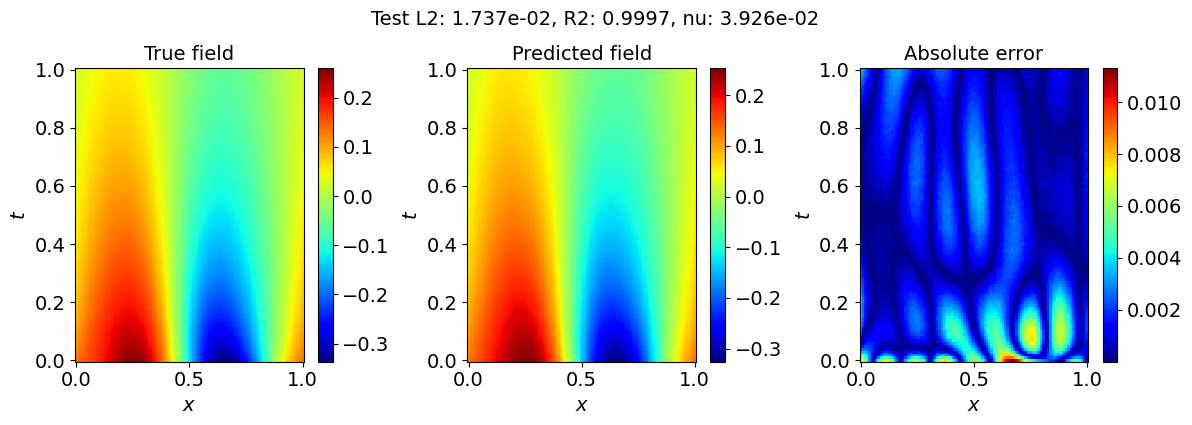

######################################################################################################################################################################################################################################
Visualizing test sample at index 300


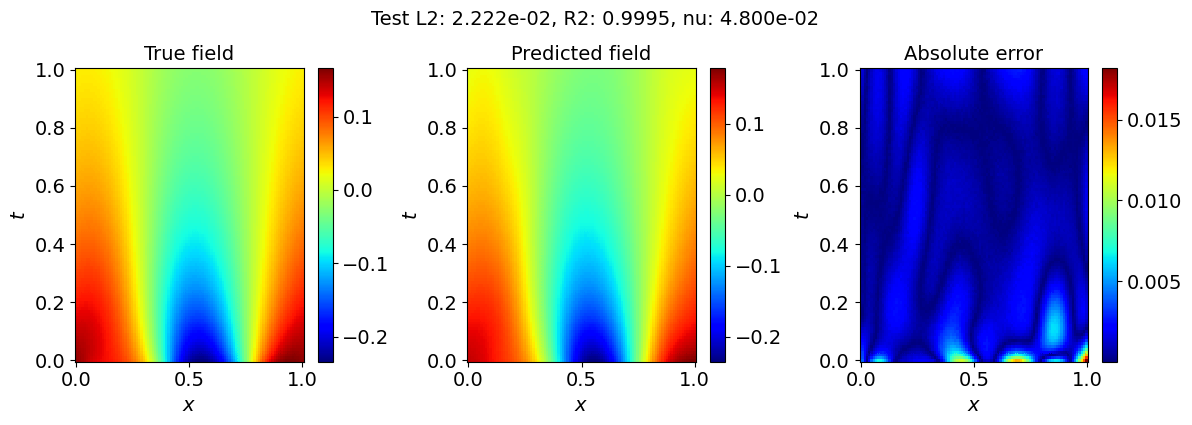

######################################################################################################################################################################################################################################
Visualizing test sample at index 400


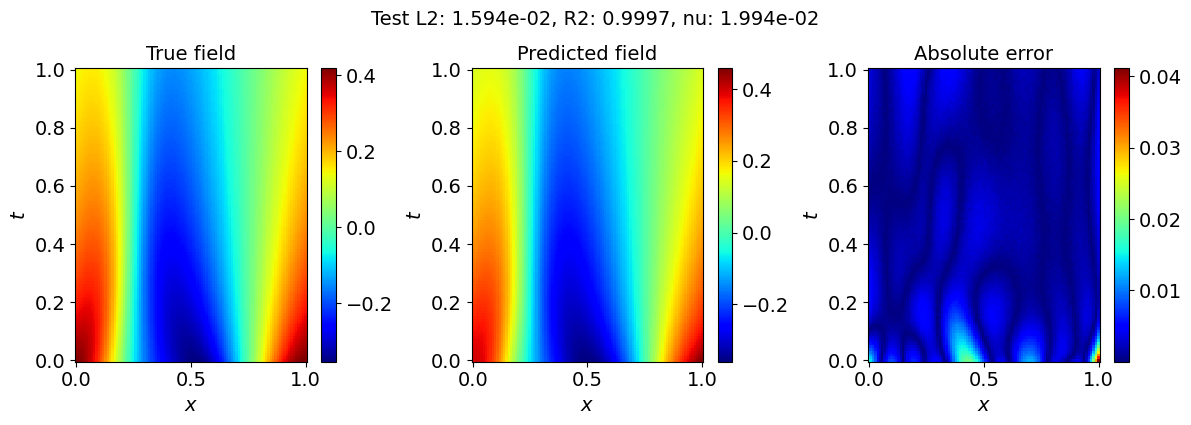

######################################################################################################################################################################################################################################
Visualizing test sample at index 500


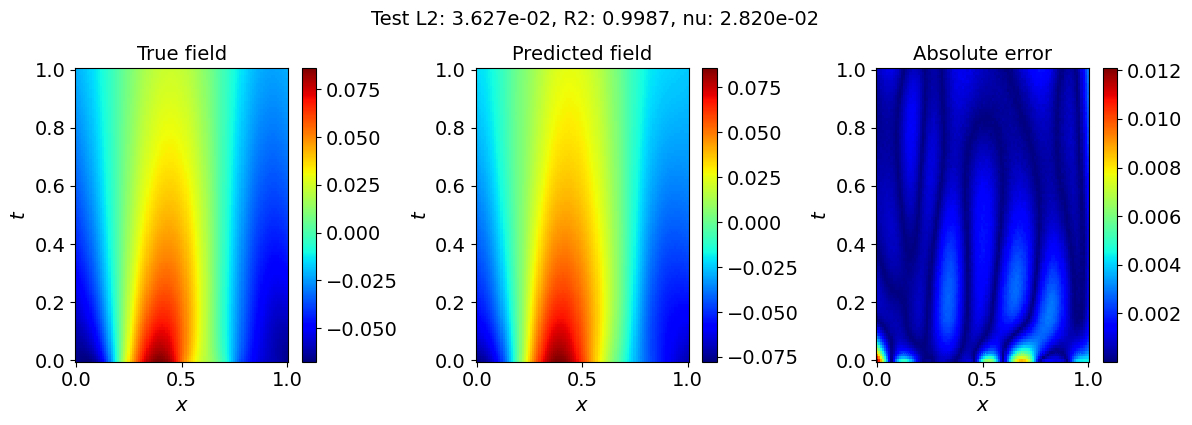

######################################################################################################################################################################################################################################
Visualizing test sample at index 600


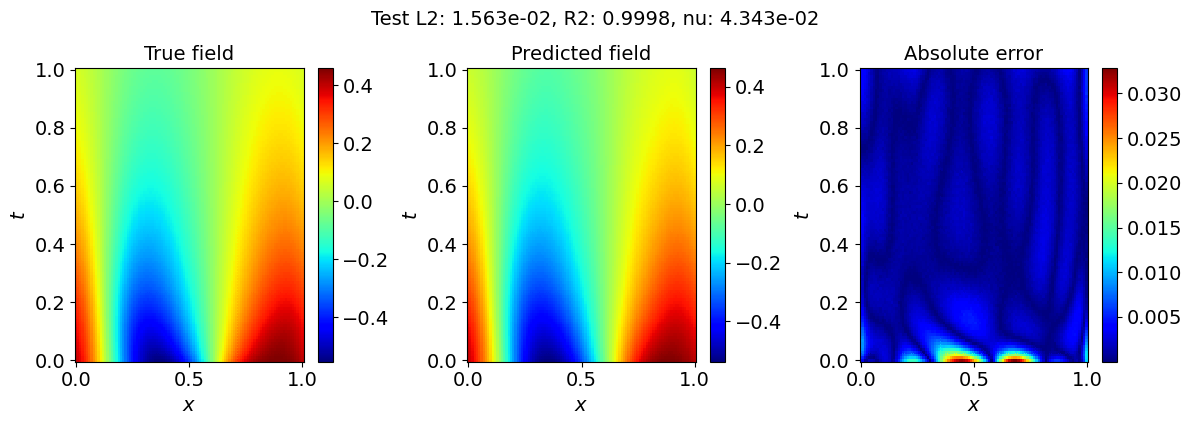

######################################################################################################################################################################################################################################
Visualizing test sample at index 700


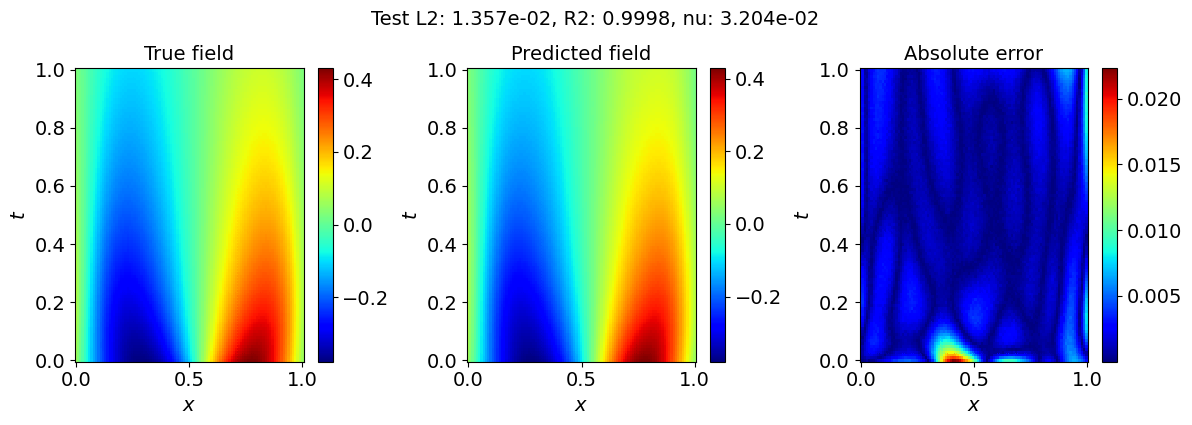

######################################################################################################################################################################################################################################
Visualizing test sample at index 800


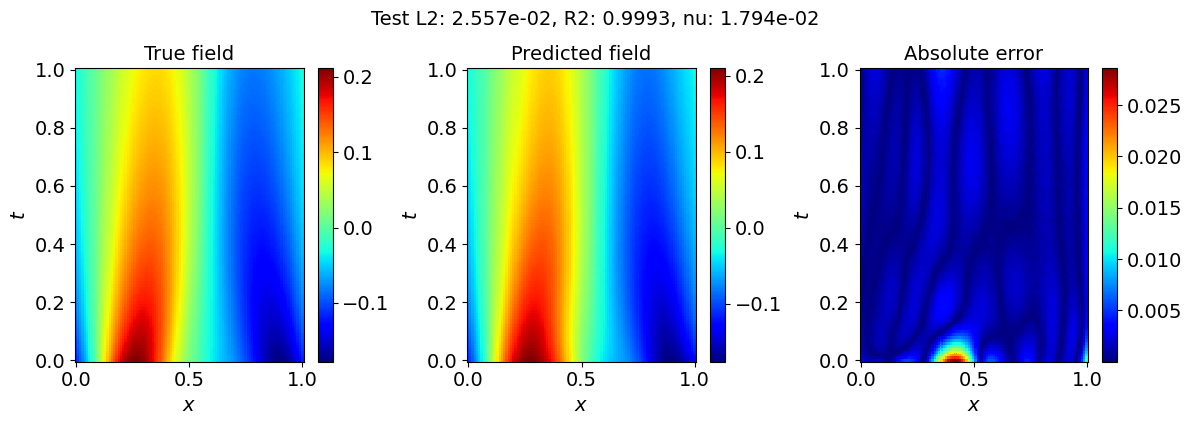

######################################################################################################################################################################################################################################
Visualizing test sample at index 900


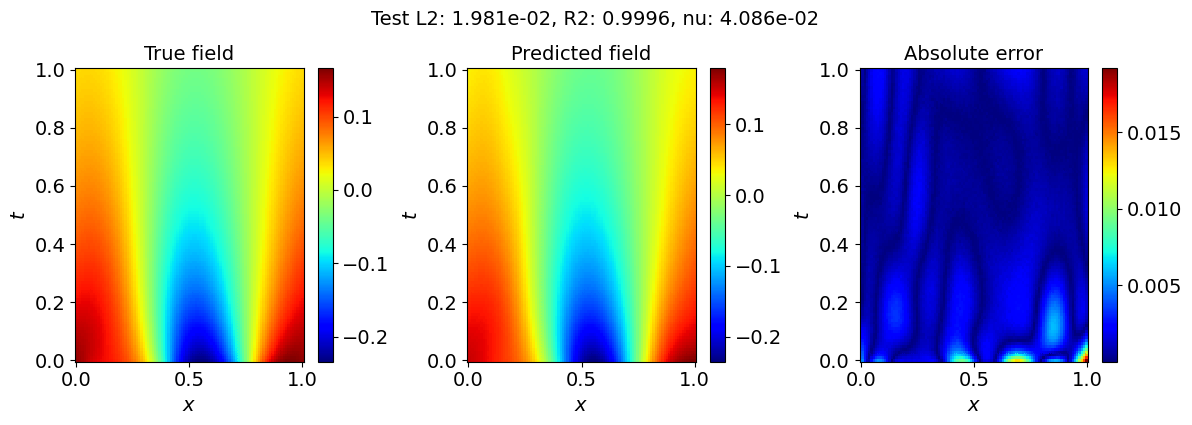

######################################################################################################################################################################################################################################
Visualizing test sample at index 1000


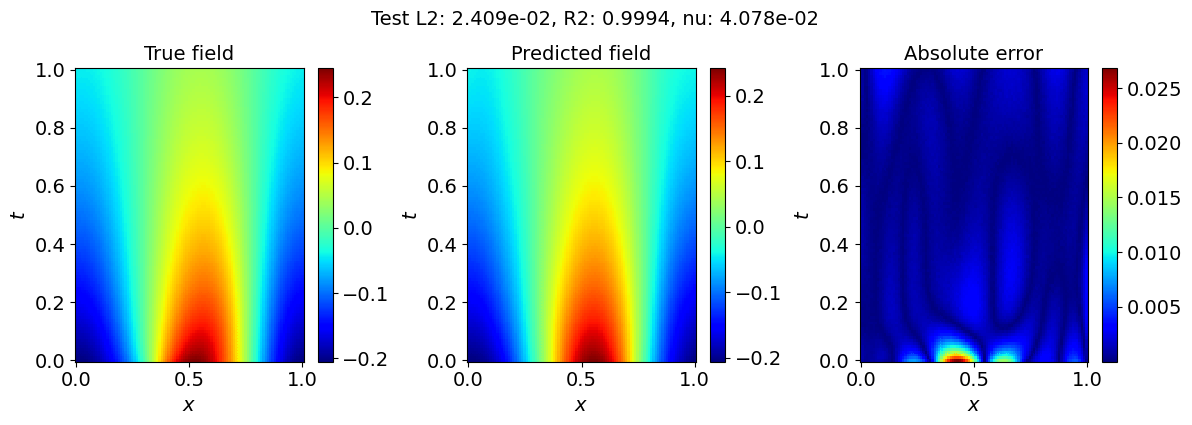

######################################################################################################################################################################################################################################
Visualizing test sample at index 1100


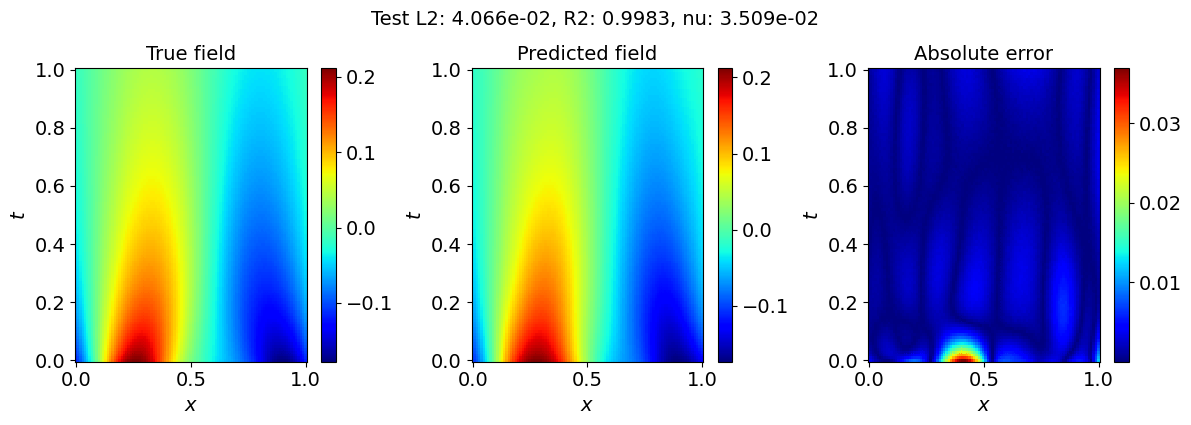

######################################################################################################################################################################################################################################
Visualizing test sample at index 1200


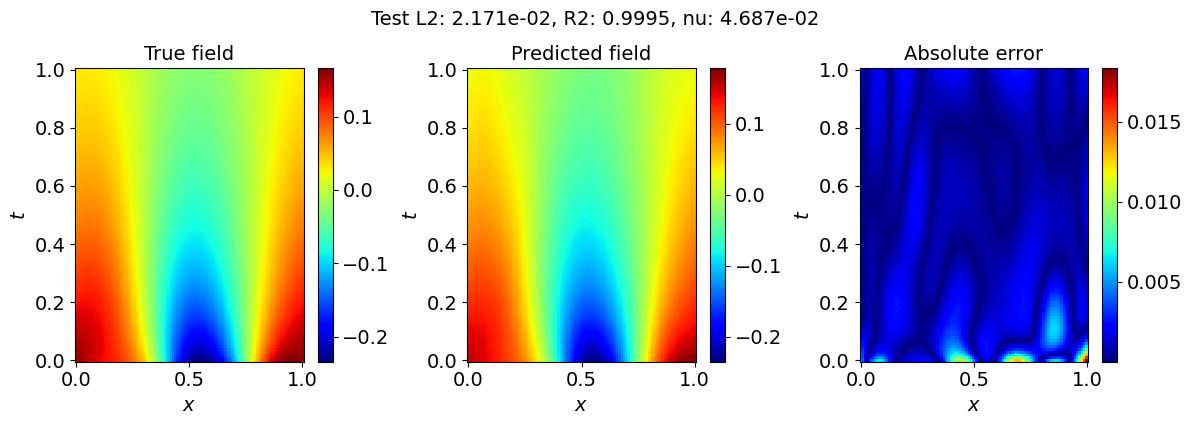

######################################################################################################################################################################################################################################
Visualizing test sample at index 1300


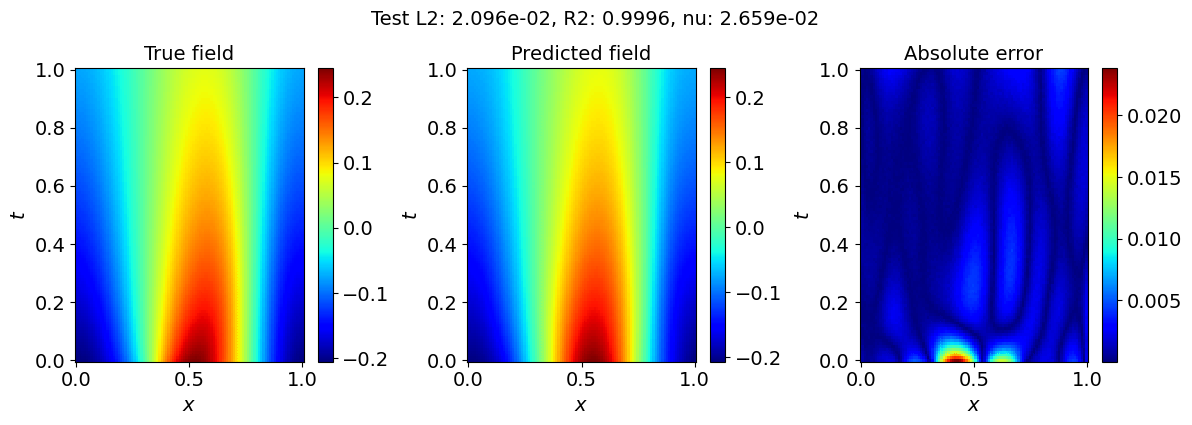

######################################################################################################################################################################################################################################
Visualizing test sample at index 1400


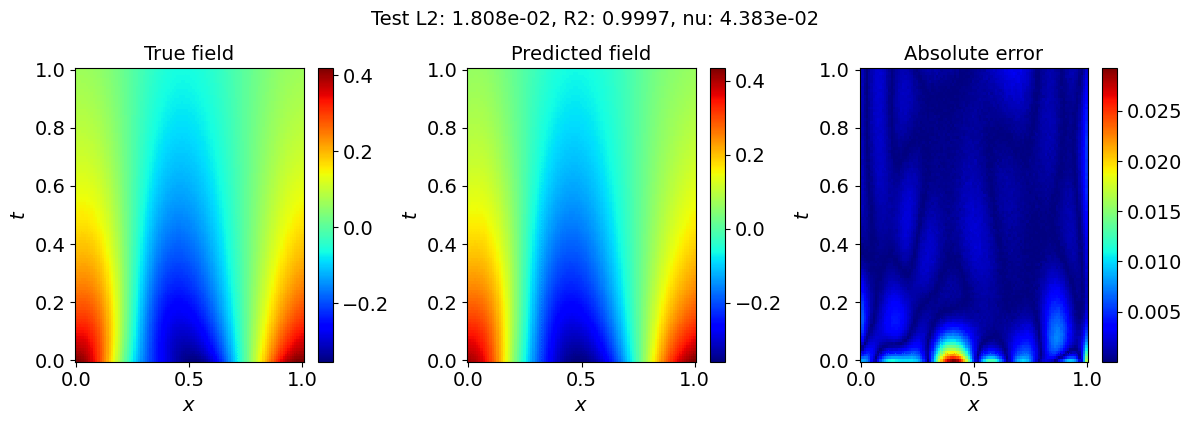

######################################################################################################################################################################################################################################
Mean MSE over test samples: 3.699e-06


In [13]:
"""# Test error function"""

def loss_test_l2_error(model_fn, params, data_output, u_sol_test, return_data=False):

    def ff_net(t_test, x_test):
        s_pred = apply_net(model_fn, params, data_output, t, x)
        return s_pred

     # Generate random indices for sampling points
    _, num_t, num_x = u_sol_test.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(300,), replace=False)
    
    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_x
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)
    
    # Create y array with (t, x) coordinates
    y = jnp.stack([t, x], axis=-1)
    
    # Sample s values from u_data
    u = u_sol_test[:, t_indices, x_indices]

    s_pred = ff_net(t, x)

    loss_test = mse(u, s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(jax.vmap(l2_norm_error)(u, s_pred))

    if return_data:
        return loss_test, l2_error, s_pred
    else:
        return loss_test, l2_error

"""# Test visualization"""

def loss_test_l2_error_one_sample(model_fn, params, data_output, u_sol_test, idx, return_data=False):

    t_test = jnp.linspace(0, 1, u_sol_test.shape[1])
    x_test = jnp.linspace(0, 1, u_sol_test.shape[2])

    xx_test, tt_test = jnp.meshgrid(x_test, t_test, indexing='ij')

    y = jnp.stack([tt_test.flatten(), xx_test.flatten()], axis=-1) #(100*100, 2)

    t = y[:,0]
    x = y[:,1]

    data_output_i = data_output[idx, :]
    data_output_i = data_output_i[jnp.newaxis,:]

    def ff_net(t_test, x_test):
        s_pred = apply_net(model_fn, params, data_output_i, t, x)
        return s_pred

    s_pred = ff_net(t, x)
    s_pred = s_pred.reshape(u_sol_test.shape[1], u_sol_test.shape[2])

    loss_test = mse(u_sol_test[idx, :, :].T, s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(l2_norm_error(u_sol_test[idx,:,:].T, s_pred))


    if return_data:
        return loss_test, l2_error, s_pred, u_sol_test[idx,:,:]
    else:
        return loss_test, l2_error

def visualize_show(model_fn, params, result_dir, epoch, data_output, u_sol_test, nu_test, idx, test=False):
    # Generate data, and obtain error
    loss_test, l2_error, s_pred, s_test = loss_test_l2_error_one_sample(model_fn, params, data_output, u_sol_test, idx, return_data=True)

    s_test = s_test.T
    
    x = jnp.linspace(0, 1, s_pred.shape[1])
    t = jnp.linspace(0, 1, s_pred.shape[0])

    x_test, t_test = jnp.meshgrid(x, t, indexing='ij')


    # Calculate R² score
    r2_value = metrics.r2_score(s_test.flatten(), s_pred.flatten())
    r2_value = float('%.4f' % r2_value)

    # Plot
    fig = plt.figure(figsize=(12, 4))

    # Adjusting layout for more vertical space
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.7, wspace=0.4, hspace=0.1)

    # Plot Exact u over time using pcolor
    ax = fig.add_subplot(1, 3, 1)
    plt.pcolor(x_test, t_test, s_test, cmap='jet', shading='auto')
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$t$', fontsize=14)
    ax.set_title('True field', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()

    # Plot Predicted u over time using pcolor
    ax = fig.add_subplot(1, 3, 2)
    plt.pcolor(x_test, t_test, s_pred, cmap='jet', shading='auto')
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$t$', fontsize=14)
    ax.set_title('Predicted field', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()

    # Plot Absolute error using pcolor

    u_diff = s_test - s_pred

    ax = fig.add_subplot(1, 3, 3)
    plt.pcolor(x_test, t_test, jnp.abs(u_diff), cmap='jet', shading='auto')
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$t$', fontsize=14)
    ax.set_title('Absolute error', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()


    if test:
        plt.suptitle(f'Test L2: {l2_error:.3e}, R2: {r2_value}, nu: {nu_test[idx]:.3e}', y=1.05, fontsize=14)
    else:
        plt.suptitle(f'Train L2: {l2_error:.3e}, R2: {r2_value:.3e}', y=1.05, fontsize=14)

    # Show or save the plot
#     if save:
#         plt.savefig(os.path.join(result_dir, f'Test_Sample_{idx}.pdf'))
    plt.show()
    plt.close()
    print(colored('#' * 230, 'green'))
    return r2_value  # Return R² score for each visualization

# Initialize an empty list to store MSE values
mse_values = []

# Loop over every 20th index to visualize and calculate R²
for i in range(u_sol_test.shape[0]):
    if i % 100 == 0:
        idx = i
        print(f"Visualizing test sample at index {idx}")

        # Visualize and calculate R² score for every 20th index
        visualize_show(model_fn, params_loaded, result_dir, epochs, data_output, u_sol_test, nu_test, idx, True)

# Calculate loss and l2 error for test samples
loss_test, l2_error = loss_test_l2_error(model_fn, params_loaded, data_output, u_sol_test, return_data=False)

# Calculate and print the mean MSE over all test samples
# mean_mse = jnp.mean(jnp.array(mse_values))
print(f"Mean MSE over test samples: {loss_test:.3e}")

In [14]:
"""# Loss function"""

def loss_res_single_sample(model_fn_nu, model_fn, params_nu, params_loaded, 
                           u_data_single, t, x, key):
    """Compute loss for a single sample on a fixed grid"""
    u_data_single = u_data_single[None, :]
    
    def f(t, x):
        return apply_net(model_fn, params_loaded, u_data_single, t, x)
    
    s = f(t, x)
    
    # Predict ν parameters
    nu_pred_all = apply_net_nu(model_fn_nu, params_nu, u_data_single)
    nu_mean_raw, nu_logstd_raw = nu_pred_all[0], nu_pred_all[1]
    
    # Apply softplus to ensure mean is positive
    nu_mean = jax.nn.softplus(nu_mean_raw)
    
    # Constrain std to be at most 30% of mean (adjust this ratio as needed)
    # This ensures samples stay within ~3 sigma = 90% of mean, so always positive
    nu_std_raw = jnp.exp(nu_logstd_raw)
    nu_std = jnp.minimum(nu_std_raw, 0.2 * nu_mean)  # Cap at 30% of mean
    
    # Reparameterization
    eps = jax.random.normal(key, shape=())
    nu_sampled = nu_mean + eps * nu_std
    nu_pred = nu_sampled
    
    # Derivatives
    _, s_x = jax.jvp(lambda x: f(t, x), (x,), (jnp.ones_like(x),))
    _, s_t = jax.jvp(lambda t: f(t, x), (t,), (jnp.ones_like(t),))
    _, s_xx = jax.jvp(lambda x: jax.jvp(lambda x: f(t, x), (x,), (jnp.ones_like(x),))[1], 
                      (x,), (jnp.ones_like(x),))
    
    # Residual
    pred = s_t + s * s_x - nu_pred * s_xx
    residual_loss = mse_single(pred)
    
    # KL divergence
    prior_mean = 0.01
    prior_std = 0.01
    
    kl_loss = 0.5 * (
        (nu_std / prior_std)**2 +
        ((nu_mean - prior_mean) / prior_std)**2 -
        1 + 
        2 * jnp.log(prior_std) - 
        2 * jnp.log(nu_std)
    )
    
    return residual_loss + 0.001 * kl_loss

def loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch, key):
    inputs, sol, nuu, _ = res_batch
    u_data, y_res = inputs
    
    # Use a fixed set of evaluation points (same for all samples)
    t = y_res[0, :, 0]
    x = y_res[0, :, 1]
    
    # Generate random keys for each sample
    keys = jax.random.split(key, u_data.shape[0])
    
    # Compute loss for all samples on the same (t, x) grid
    losses = jax.vmap(
        lambda u, k: loss_res_single_sample(
            model_fn_nu, model_fn, params_nu, params_loaded, u, t, x, k
        )
    )(u_data, keys)
    
    # Return mean over all samples
    return jnp.mean(losses)

def loss_data(model_fn, params, data_batch):

    inputs, outputs, _,_ = data_batch
    u_data, y = inputs

    t = y[1, :, 0] # pick y for one sample (y is same for all samples)
    x = y[1, :, 1]

    s_pred = apply_net(model_fn, params, u_data, t, x)
    s_pred = s_pred.reshape(outputs.shape[0], outputs.shape[1])

    loss = mse(outputs, s_pred)
    return loss

def loss_fn(model_fn_nu, model_fn, params, res_batch, data_batch, key):
    params_loaded, params_nu = params
    loss_res_i = loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch, key)
    loss_data_i = loss_data(model_fn, params_loaded, data_batch)

    loss_value =  1.0 * loss_res_i  + 1.0*loss_data_i

    return loss_value

In [15]:
"""# set the model"""

# Initialize model and params

branch_nu_layers = [branch_nu_layers] if isinstance(branch_nu_layers, int) else branch_nu_layers

# add output features to trunk and branch layers
branch_nu_layers = branch_nu_layers + [hidden_dim_nu]

# Convert list to tuples
branch_nu_layers = tuple(branch_nu_layers)

num_outputs = 1
model_nu = MLP_nu(branch_nu_layers, num_outputs)

params_nu = model_nu.init(key, jnp.ones(shape=(1, n_sensors * branch_input_features)))

# Print model from parameters
print('--- model_summary ---')
# count total params
total_params_nu = sum(x.size for x in jax.tree_util.tree_leaves(params_nu))
print(f'total params nu: {total_params_nu}')
print('--- model_summary ---')

# model function
model_fn_nu = jax.jit(model_nu.apply)

--- model_summary ---
total params nu: 27715
--- model_summary ---


In [16]:
# """# Test error function"""

# def loss_test_l2_error_nu(model_fn_nu, params_nu, data_output, u_sol_test, nu_test, return_data=False):

#     nu_pred = apply_net_nu(model_fn_nu, params_nu, u_sol_test)

#     loss_test = mse(nu_test, nu_pred)

#     def rel_abs_error(a, b):
#         """Calculate realtive absolute error"""
#         return jnp.abs(a - b)/a

#     l2_error = jnp.mean(jax.vmap(rel_abs_error)(nu_test, nu_pred))

#     if return_data:
#         return loss_test, l2_error, nu_pred
#     else:
#         return loss_test, l2_error

In [17]:
"""# Define optimiser  of nu prediction"""

# Define optimizer with optax (ADAM)
# optimizer

lr_scheduler = optax.exponential_decay(lr, transition_steps, decay_rate)

# lr_scheduler = optax.constant_schedule(1e-3)

optimizer = optax.adam(learning_rate=lr_scheduler)

params = (params_loaded, params_nu) # include both parameters for training
opt_state = optimizer.init(params)

# Data
data_data = iter(data_dataset)
res_data = iter(res_dataset)


# create dir for saving results
result_dir = os.path.join(os.getcwd(), os.path.join(result_dir, f"results_inv_burgers_nu_{seed}"))
log_file = os.path.join(result_dir, 'log.csv')
# Create directory
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
if os.path.exists(os.path.join(result_dir, 'vis')):
    shutil.rmtree(os.path.join(result_dir, 'vis'))
if os.path.exists(log_file):
    os.remove(log_file)


with open(log_file, 'a') as f:
    f.write('epoch,loss,loss_res_value,loss_data_value,runtime\n')

In [18]:
"""# save nu model"""

# Usage:
save = True
# Saving
if save:
    save_model_params(params, result_dir)
    
"""# training loop"""

ic_and_nu_train[:, :-1].shape

(8500, 101)

In [19]:


"""# Training loop"""

# Iterations
epochs = epochs  # Assuming 'epochs' is defined elsewhere
epochs = 120000
log_iter = 1000
best_mse = float('inf')  # Initialize with infinity
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_0.pkl')
print("Saved initial model at iteration 0")
# Training loop
for it in range(epochs):
    if it == 1:
        # start timer and exclude first iteration (compile time)
        start = time.time()
    # Fetch data
    res_batch = next(res_data)
    data_batch = next(data_data)

    # Do Step

    loss, params, opt_state = step(optimizer, loss_fn, model_fn_nu, model_fn, opt_state,
                                   params, res_batch, data_batch, key)
    if it % log_iter == 0:
        # Compute losses
        # def loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch):
        params_loaded, params_nu = params
        loss = loss_fn(model_fn_nu, model_fn, params, res_batch, data_batch, key)
        loss_res_value = loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch, key)
        loss_data_value = loss_data(model_fn, params_loaded, data_batch)

        # loss_test, rel_error = loss_test_l2_error(model_fn, params_loaded, data_output, u_sol_test, return_data=False)
        if loss <  best_mse:
            best_mse = loss
            # Save the model as it's the best so far
            params = (params_loaded, params_nu)
            save_model_params(params, result_dir, filename='model_params_best.pkl')
            print(f"New best model saved at iteration {it} with test MSE: {loss:.2e}")

        # get runtime
        if it == 0:
            runtime = 0
        else:
            runtime = time.time() - start

        # Print losses
        print(f"Iteration {it+1}/{epochs}")
        print(f"Trian_loss: {loss:.2e}, "
              f"loss_res: {loss_res_value:.2e}, loss_data: {loss_data_value:.2e} , runtime: {runtime:06.2f}")

        # Save results
        with open(log_file, 'a') as f:
            f.write(f'{it+1}, {loss}, '
                    f'{loss_res_value}, {loss_data_value}, {runtime}\n')

# Save results
runtime = time.time() - start
# Save initial model at 0th iteration
params = (params_loaded, params_nu)
save_model_params(params, result_dir, filename='model_params_last.pkl')
print("Saved model at end of training")
with open(log_file, 'a') as f:
    f.write(f'{it + 1}, {loss}, '
            f' {loss_res_value}, {loss_data_value}, {runtime}\n')

Saved initial model at iteration 0
New best model saved at iteration 0 with test MSE: 1.92e+01
Iteration 1/120000
Trian_loss: 1.92e+01, loss_res: 1.91e+01, loss_data: 1.11e-02 , runtime: 000.00
New best model saved at iteration 1000 with test MSE: 6.84e-01
Iteration 1001/120000
Trian_loss: 6.84e-01, loss_res: 6.74e-01, loss_data: 9.88e-03 , runtime: 003.89
New best model saved at iteration 2000 with test MSE: 3.14e-01
Iteration 2001/120000
Trian_loss: 3.14e-01, loss_res: 3.06e-01, loss_data: 8.20e-03 , runtime: 007.67
New best model saved at iteration 3000 with test MSE: 1.65e-01
Iteration 3001/120000
Trian_loss: 1.65e-01, loss_res: 1.58e-01, loss_data: 6.64e-03 , runtime: 011.46
New best model saved at iteration 4000 with test MSE: 9.39e-02
Iteration 4001/120000
Trian_loss: 9.39e-02, loss_res: 8.86e-02, loss_data: 5.26e-03 , runtime: 015.25
New best model saved at iteration 5000 with test MSE: 5.60e-02
Iteration 5001/120000
Trian_loss: 5.60e-02, loss_res: 5.19e-02, loss_data: 4.05e-03

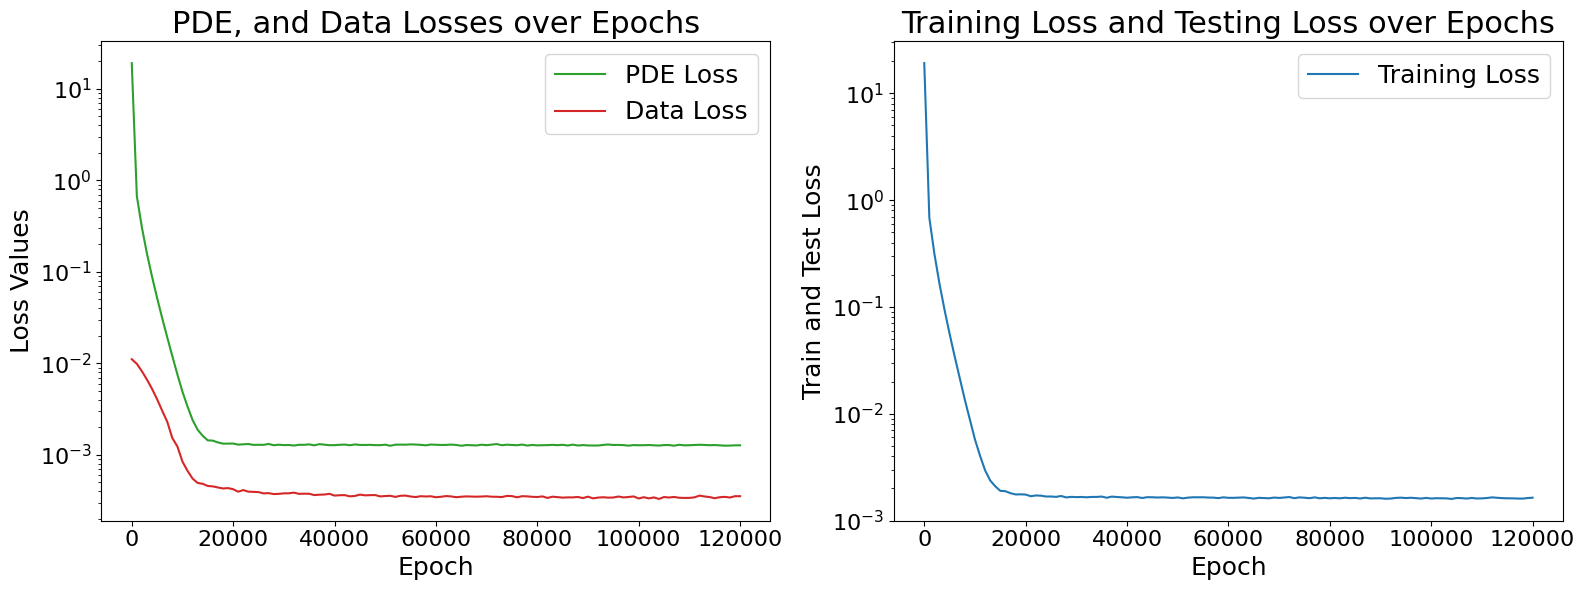

Plots saved to /scratch4/sgoswam4/Dibakar/INV_DON/Burgers_dist/./results_inv_burgers_nu_0/train_and_test_loss_plots.pdf


In [20]:
"""# Loss plots"""

# Read the CSV file
csv_file = os.path.join(result_dir, "log.csv")  # Assuming the file is named "log.csv"
df = pd.read_csv(csv_file)

# Create the figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Set color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Left plot: epoch vs loss_ics_value, loss_bcs_value, and loss_res_value
ax1.plot(df['epoch'], df['loss_res_value'], label='PDE Loss', color=colors[2], linestyle='-')
ax1.plot(df['epoch'], df['loss_data_value'], label='Data Loss', color=colors[3], linestyle='-')
ax1.set_yscale("log")
ax1.set_xlabel('Epoch', fontsize=18)
ax1.set_ylabel('Loss Values', fontsize=18)
ax1.set_title('PDE, and Data Losses over Epochs', fontsize=22)
ax1.legend(loc='best', fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Right plot: epoch vs loss and l2err_val
ax2.plot(df['epoch'], df['loss'], label='Training Loss', color=colors[0], linestyle='-')
# ax2.plot(df['epoch'], df['loss_test'], label='Testing Loss', color=colors[1], linestyle='-')
ax2.set_yscale("log")
ax2.set_xlabel('Epoch', fontsize=18)
ax2.set_ylabel('Train and Test Loss', fontsize=18)
ax2.set_title('Training Loss and Testing Loss over Epochs', fontsize=22)
ax2.legend(loc='best', fontsize=18)
ax2.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Adjust layout and save the figure
plt.tight_layout()
output_file = os.path.join(result_dir, "train_and_test_loss_plots.pdf")
plt.savefig(output_file, dpi=300)
plt.show()
plt.close()

print(f"Plots saved to {output_file}")

In [18]:
ic_test = ic_and_nu_test[:,:-1]
nu_test = ic_and_nu_test[:,-1]
u_sol_test.shape

(1500, 101, 101)

In [19]:
params = load_model_params('/home/droysar1/scr4_sgoswam4/Dibakar/INV_DON/Burgers_dist/results_inv_burgers_nu_0/model_params_best.pkl')
params_loaded, params_nu = params

In [20]:
# Your usage code
N = 101
x = np.linspace(0, 1, N, endpoint=False)
sample = 10
u0 = ic_test[sample]
u_data = data_output[sample]

# Network predicts mean and std of ν
nu_pred_all = apply_net_nu(model_fn_nu, params_nu, u_data)



In [21]:
# import numpy as np

# def burgers_solver(u0, nu, T=1.0, dt=1e-3, N=100):

#     # Spatial grid
#     L = 1.0
#     dx = L / N
#     x = np.linspace(0, L, N, endpoint=False)

#     # Initialize
#     u = u0.copy()
#     num_steps = int(T / dt)
#     sol = np.zeros((num_steps + 1, N))
#     sol[0] = u.copy()

#     # Time stepping loop
#     for n in range(num_steps):
#         # Compute spatial derivatives
#         u_x = np.zeros_like(u)
#         u_xx = np.zeros_like(u)

#         # Periodic BC
#         u_p = np.roll(u, -1)
#         u_m = np.roll(u, 1)

#         # Upwind scheme for convection
#         for i in range(N):
#             if u[i] >= 0:
#                 u_x[i] = (u[i] - u_m[i]) / dx
#             else:
#                 u_x[i] = (u_p[i] - u[i]) / dx

#         # Central difference for diffusion
#         u_xx = (u_p - 2 * u + u_m) / dx**2

#         # Update step
#         u_new = u - dt * u * u_x + nu * dt * u_xx
#         u = u_new

#         sol[n + 1] = u

#     return x, sol


# N = 101
# x = np.linspace(0, 1, N, endpoint=False)
# sample = 4
# u0 = ic_test[sample]
# u_data = data_output[sample]

# # Network predicts mean and std of ν
# nu_pred_all = apply_net_nu(model_fn_nu, params_nu, u_data)

# nu_pred_mean, nu_pred_logstd = nu_pred_all[0], nu_pred_all[1]

# nu_pred_std = jnp.exp(nu_pred_logstd)

# # Sample ε ~ N(0, I) with same shape as mean
# eps_key, _ = jax.random.split(key)
# eps = jax.random.normal(eps_key, shape=nu_pred_mean.shape)

# # Reparameterize ν
# nu_sampled = nu_pred_mean + eps * nu_pred_std

# print("nu_pred_mean: ", nu_pred_mean)
# print("nu_pred_std: ", nu_pred_std)

# print("nu_sampled: ", nu_sampled)

# x, sol_pred = burgers_solver(u0, nu_sampled, T=1.0, dt=1e-2, N=N)
# print("Simulation complete. Solution shape:", sol_pred.shape)


In [22]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

def burgers_solver(u0, nu, T=1.0, dt=1e-2, N=100):
    # Convert JAX arrays to NumPy if needed
    if hasattr(u0, 'device'):
        u0 = np.array(u0)
    if hasattr(nu, 'device'):
        nu = float(np.array(nu))
    
    # Spatial grid
    L = 1.0
    dx = L / N
    x = np.linspace(0, L, N, endpoint=False)
    
    # Initialize
    u = u0.copy()
    num_steps = int(T / dt)
    sol = np.zeros((num_steps + 1, N))
    sol[0] = u.copy()
    
    # Build implicit diffusion operator (tridiagonal with periodic BC)
    alpha = nu * dt / dx**2
    # Main diagonal
    main_diag = (1 + 2 * alpha) * np.ones(N)
    # Off diagonals
    off_diag = -alpha * np.ones(N - 1)
    
    # Create the matrix with periodic boundary conditions
    A = diags([main_diag, off_diag, off_diag, [-alpha], [-alpha]], 
              [0, -1, 1, N-1, -(N-1)], 
              shape=(N, N), 
              format='csr')
    
    # Time stepping loop
    for n in range(num_steps):
        # Periodic BC using roll
        u_p = np.roll(u, -1)  # u[i+1]
        u_m = np.roll(u, 1)   # u[i-1]
        
        # Vectorized upwind scheme for convection term (explicit)
        u_x = np.where(u >= 0, 
                       (u - u_m) / dx,      # backward difference
                       (u_p - u) / dx)      # forward difference
        
        # Right hand side: u - dt * u * u_x (convection treated explicitly)
        rhs = u - dt * u * u_x
        
        # Solve implicit system for diffusion: (I + nu*dt*D2) * u_new = rhs
        u = spsolve(A, rhs)
        
        sol[n + 1] = u
    
    return x, sol

# Your usage code
N = 101
x = np.linspace(0, 1, N, endpoint=False)
sample = 10
u0 = ic_test[sample]
u_data = data_output[sample]

# Network predicts mean and std of ν
nu_pred_all = apply_net_nu(model_fn_nu, params_nu, u_data)
nu_pred_mean, nu_pred_logstd = nu_pred_all[0], nu_pred_all[1]
nu_pred_mean = jax.nn.softplus(nu_pred_mean)
nu_pred_std = jnp.exp(nu_pred_logstd)
nu_pred_std = jnp.minimum(nu_pred_std, 0.2 * nu_pred_mean)  # Cap at 30% of mean

# Sample ε ~ N(0, I) with same shape as mean
eps_key, _ = jax.random.split(key)
eps = jax.random.normal(eps_key, shape=nu_pred_mean.shape)

# Reparameterize ν
nu_sampled = nu_pred_mean + eps * nu_pred_std
# nu_sampled = jax.nn.softplus(nu_sampled)

nu_test_true = nu_test[sample]

print("nu_pred_mean: ", nu_pred_mean)
print("nu_pred_std: ", nu_pred_std)
print("nu_sampled: ", nu_sampled)
print("nu_test_true: ", nu_test_true)


# Now works stably with dt=1e-2
x, sol_pred = burgers_solver(u0, nu_sampled, T=1.0, dt=1e-2, N=N)
print("Simulation complete. Solution shape:", sol_pred.shape)


nu_pred_mean:  0.015825413
nu_pred_std:  0.0031650828
nu_sampled:  0.01628084
nu_test_true:  0.023146292
Simulation complete. Solution shape: (101, 101)


In [23]:
dsol_pred_loc, location_test, y_test = extract_points(sol_pred.reshape(-1, 101, 101), p_data_train)
dsol_pred_loc = dsol_pred_loc[0]

In [24]:
u_data.shape, dsol_pred_loc.shape

((300,), (300,))

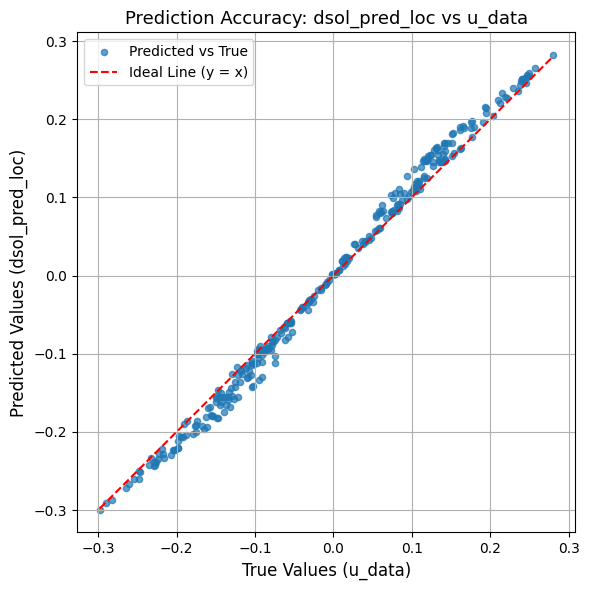

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(u_data, dsol_pred_loc, s=20, alpha=0.7, label='Predicted vs True')
plt.plot([u_data.min(), u_data.max()],
         [u_data.min(), u_data.max()],
         'r--', label='Ideal Line (y = x)')

plt.xlabel("True Values (u_data)", fontsize=12)
plt.ylabel("Predicted Values (dsol_pred_loc)", fontsize=12)
plt.title("Prediction Accuracy: dsol_pred_loc vs u_data", fontsize=13)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

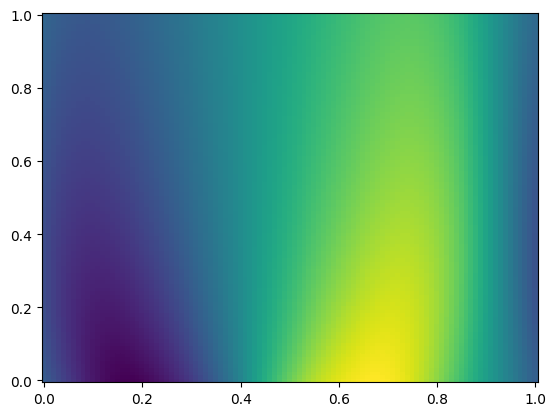

In [26]:
x = jnp.linspace(0, 1, sol_pred.shape[1])
t = jnp.linspace(0, 1, sol_pred.shape[0])

x_test, t_test = jnp.meshgrid(x, t, indexing='ij')

plt.pcolor(x_test, t_test, sol_pred.T)

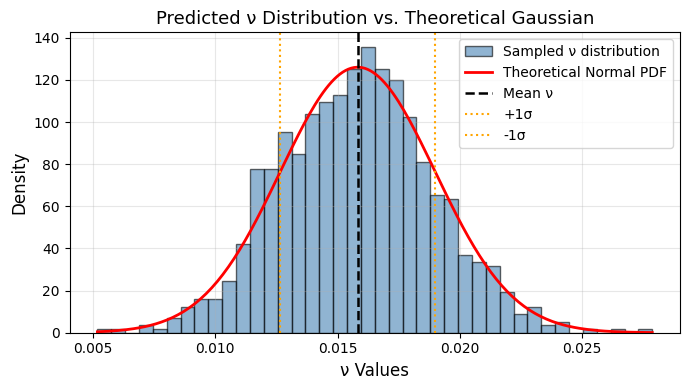

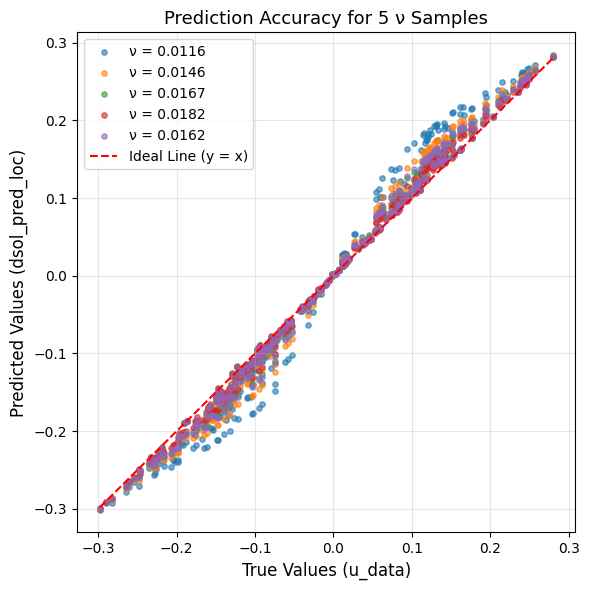

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -------------------------------------------------------------------
# Step 1: Generate multiple samples of ν
# -------------------------------------------------------------------
num_nu_samples = 1000  # number of random samples for the histogram
eps_key, _ = jax.random.split(key)
eps_multi = jax.random.normal(eps_key, shape=(num_nu_samples,) + nu_pred_mean.shape)

# Reparameterize ν for all samples
nu_samples = nu_pred_mean[None, ...] + eps_multi * nu_pred_std[None, ...]
nu_samples_flat = np.array(nu_samples).flatten()

# -------------------------------------------------------------------
# Step 2: Plot histogram + theoretical normal distribution
# -------------------------------------------------------------------
plt.figure(figsize=(7, 4))

# Histogram of empirical samples
count, bins, _ = plt.hist(
    nu_samples_flat,
    bins=40,
    density=True,
    alpha=0.6,
    color='steelblue',
    edgecolor='black',
    label='Sampled ν distribution'
)

# Compute theoretical normal PDF
x_range = np.linspace(min(nu_samples_flat), max(nu_samples_flat), 200)
pdf = norm.pdf(x_range, float(nu_pred_mean), float(nu_pred_std))

# Overlay theoretical Gaussian curve
plt.plot(x_range, pdf, 'r-', linewidth=2, label='Theoretical Normal PDF')

# Mean and ±1σ lines
plt.axvline(float(nu_pred_mean), color='black', linestyle='--', linewidth=1.8, label='Mean ν')
plt.axvline(float(nu_pred_mean + nu_pred_std), color='orange', linestyle=':', label='+1σ')
plt.axvline(float(nu_pred_mean - nu_pred_std), color='orange', linestyle=':', label='-1σ')

# Labels and aesthetics
plt.xlabel("ν Values", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Predicted ν Distribution vs. Theoretical Gaussian", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Step 3: Select and simulate a few ν samples to visualize effect
# -------------------------------------------------------------------
num_samples_to_plot = 5  # you can make this 10 if desired
sample_indices = np.linspace(0, num_nu_samples - 1, num_samples_to_plot, dtype=int)
nu_subset = nu_samples[sample_indices]

plt.figure(figsize=(6, 6))
for i, nu_val in enumerate(nu_subset):
    nu_scalar = float(np.array(nu_val))
    x, sol_pred = burgers_solver(u0, nu_scalar, T=1.0, dt=1e-2, N=N)

    dsol_pred_loc, _, _ = extract_points(sol_pred.reshape(-1, 101, 101), p_data_train)
    dsol_pred_loc = dsol_pred_loc[0]

    plt.scatter(u_data, dsol_pred_loc, s=15, alpha=0.6, label=f"ν = {nu_scalar:.4f}")

# Add y=x reference
plt.plot([u_data.min(), u_data.max()],
         [u_data.min(), u_data.max()],
         'r--', label='Ideal Line (y = x)')

plt.xlabel("True Values (u_data)", fontsize=12)
plt.ylabel("Predicted Values (dsol_pred_loc)", fontsize=12)
plt.title(f"Prediction Accuracy for {num_samples_to_plot} ν Samples", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

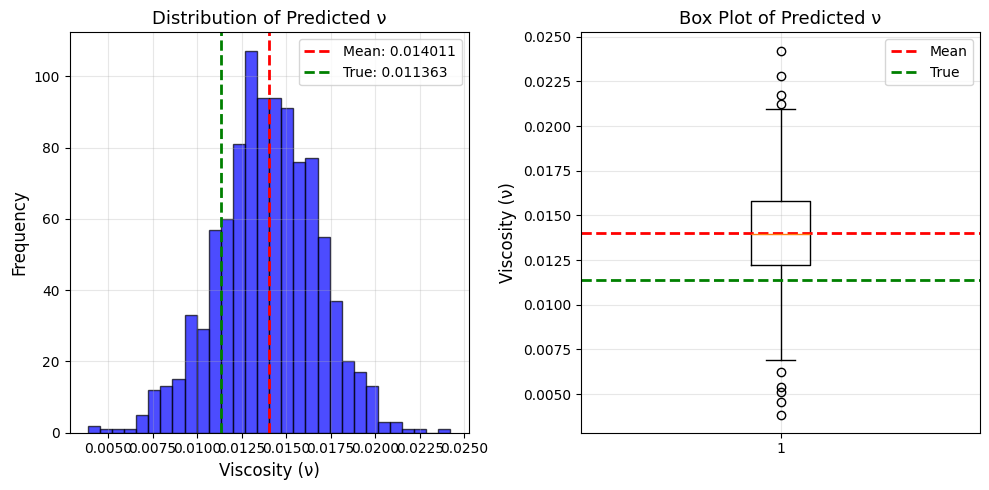

Nu predictions summary:
  Mean: 0.014011
  Std: 0.002802
  True: 0.011363
  Sample range: [0.003857, 0.024225]


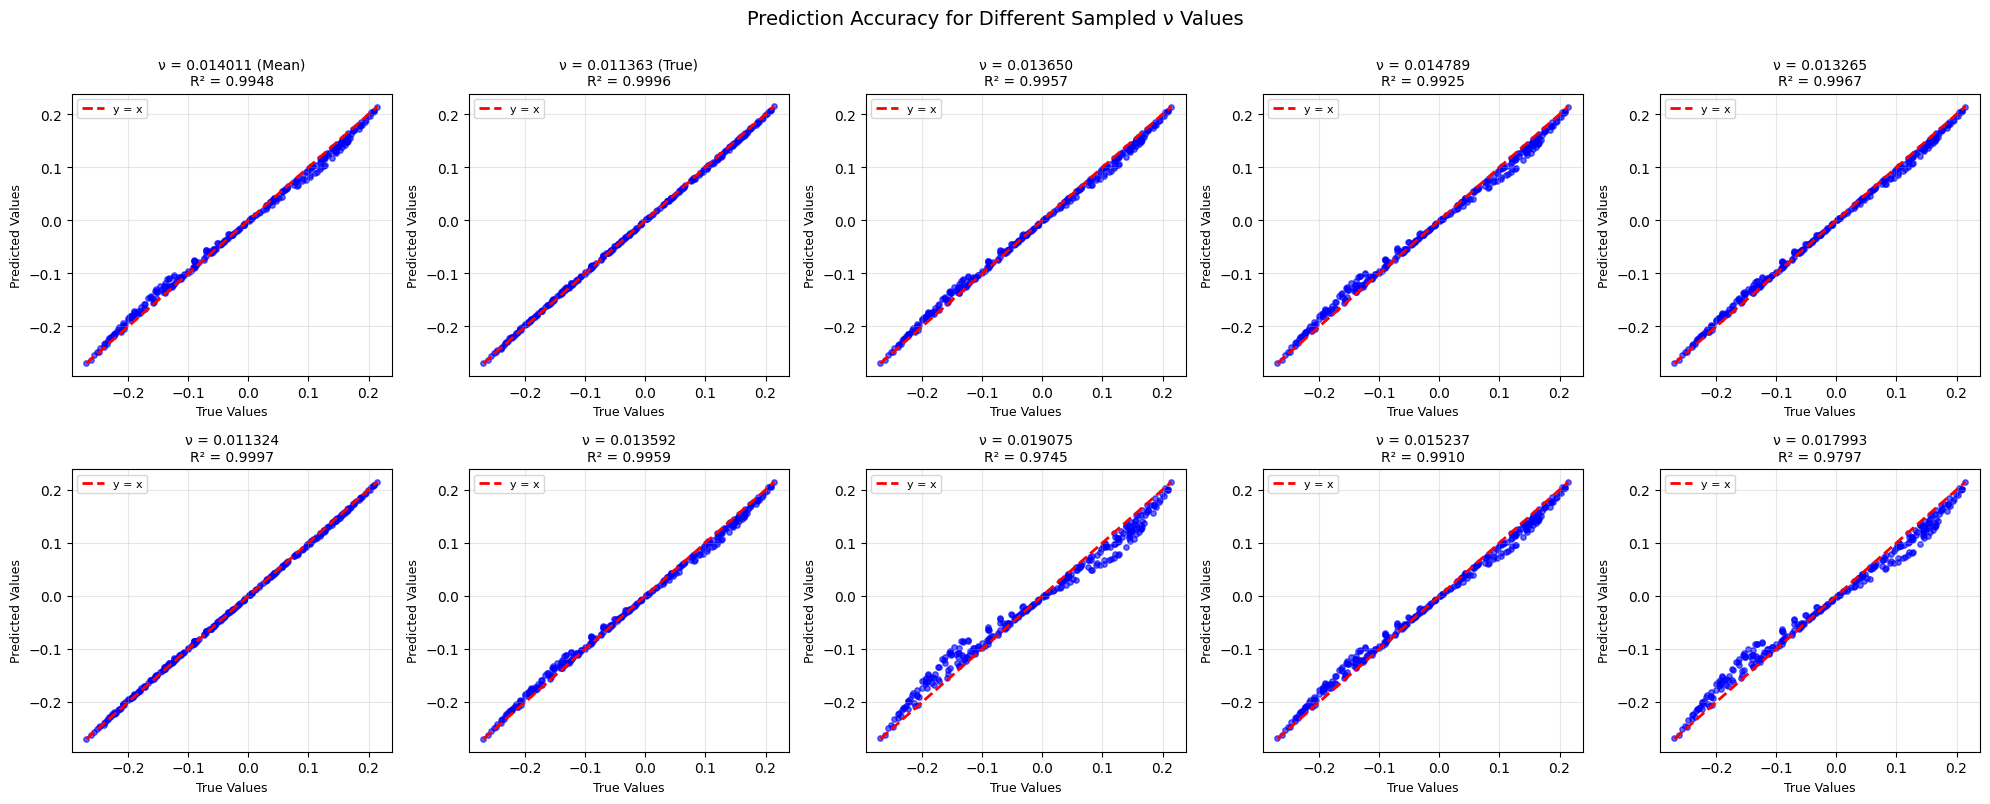

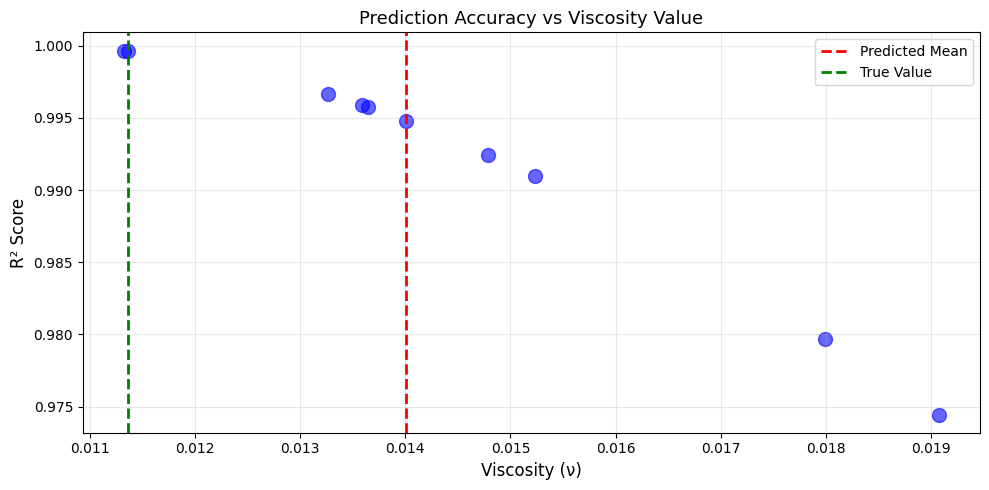


R² scores for different ν values:
  ν = 0.014011: R² = 0.9948
  ν = 0.011363: R² = 0.9996
  ν = 0.013650: R² = 0.9957
  ν = 0.014789: R² = 0.9925
  ν = 0.013265: R² = 0.9967
  ν = 0.011324: R² = 0.9997
  ν = 0.013592: R² = 0.9959
  ν = 0.019075: R² = 0.9745
  ν = 0.015237: R² = 0.9910
  ν = 0.017993: R² = 0.9797


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

def burgers_solver(u0, nu, T=1.0, dt=1e-2, N=100):
    """Solve Burgers equation with given initial condition and viscosity"""
    # Convert JAX arrays to NumPy if needed
    if hasattr(u0, 'device'):
        u0 = np.array(u0)
    if hasattr(nu, 'device'):
        nu = float(np.array(nu))
    
    # Spatial grid
    L = 1.0
    dx = L / N
    x = np.linspace(0, L, N, endpoint=False)
    
    # Initialize
    u = u0.copy()
    num_steps = int(T / dt)
    sol = np.zeros((num_steps + 1, N))
    sol[0] = u.copy()
    
    # Build implicit diffusion operator (tridiagonal with periodic BC)
    alpha = nu * dt / dx**2
    main_diag = (1 + 2 * alpha) * np.ones(N)
    off_diag = -alpha * np.ones(N - 1)
    
    # Create the matrix with periodic boundary conditions
    A = diags([main_diag, off_diag, off_diag, [-alpha], [-alpha]], 
              [0, -1, 1, N-1, -(N-1)], 
              shape=(N, N), 
              format='csr')
    
    # Time stepping loop
    for n in range(num_steps):
        # Periodic BC using roll
        u_p = np.roll(u, -1)  # u[i+1]
        u_m = np.roll(u, 1)   # u[i-1]
        
        # Vectorized upwind scheme for convection term (explicit)
        u_x = np.where(u >= 0, 
                       (u - u_m) / dx,      # backward difference
                       (u_p - u) / dx)      # forward difference
        
        # Right hand side
        rhs = u - dt * u * u_x
        
        # Solve implicit system for diffusion
        u = spsolve(A, rhs)
        
        sol[n + 1] = u
    
    return x, sol


# ============================================================================
# STEP 1: Sample multiple nu values from the predicted distribution
# ============================================================================
N = 101
x = np.linspace(0, 1, N, endpoint=False)
sample = 40
u0 = ic_test[sample]
u_data = data_output[sample]

# Get network predictions
nu_pred_all = apply_net_nu(model_fn_nu, params_nu, u_data)
nu_pred_mean, nu_pred_logstd = nu_pred_all[0], nu_pred_all[1]
nu_pred_mean = jax.nn.softplus(nu_pred_mean)
nu_pred_std = jnp.exp(nu_pred_logstd)
nu_pred_std = jnp.minimum(nu_pred_std, 0.2 * nu_pred_mean)  # Cap at 30% of mean

nu_test_true = nu_test[sample]

# Sample multiple nu values (let's do 100 samples for distribution)
n_samples_dist = 1000
nu_samples_dist = []
for i in range(n_samples_dist):
    eps_key, key = jax.random.split(key if i == 0 else eps_key)
    eps = jax.random.normal(eps_key, shape=nu_pred_mean.shape)
    nu_sampled = nu_pred_mean + eps * nu_pred_std
    nu_sampled = nu_sampled

    nu_samples_dist.append(float(np.array(nu_sampled)))

# ============================================================================
# STEP 2: Plot distribution of predicted nu
# ============================================================================
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(nu_samples_dist, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(float(np.array(nu_pred_mean)), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {float(np.array(nu_pred_mean)):.6f}')
plt.axvline(float(np.array(nu_test_true)), color='green', linestyle='--', 
            linewidth=2, label=f'True: {float(np.array(nu_test_true)):.6f}')
plt.xlabel('Viscosity (ν)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Predicted ν', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(nu_samples_dist, vert=True)
plt.axhline(float(np.array(nu_pred_mean)), color='red', linestyle='--', 
            linewidth=2, label='Mean')
plt.axhline(float(np.array(nu_test_true)), color='green', linestyle='--', 
            linewidth=2, label='True')
plt.ylabel('Viscosity (ν)', fontsize=12)
plt.title('Box Plot of Predicted ν', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Nu predictions summary:")
print(f"  Mean: {float(np.array(nu_pred_mean)):.6f}")
print(f"  Std: {float(np.array(nu_pred_std)):.6f}")
print(f"  True: {float(np.array(nu_test_true)):.6f}")
print(f"  Sample range: [{min(nu_samples_dist):.6f}, {max(nu_samples_dist):.6f}]")

# ============================================================================
# STEP 3: Pick specific nu values and compare predictions
# ============================================================================
n_test_samples = 10  # Number of different nu values to test

# Select specific nu samples (including mean, true, and random samples)
nu_test_values = [float(np.array(nu_pred_mean))]  # Start with mean
nu_test_values.append(float(np.array(nu_test_true)))  # Add true value

# Add some random samples from the distribution
np.random.seed(2)
random_indices = np.random.choice(len(nu_samples_dist), 
                                 size=n_test_samples-2, 
                                 replace=False)
for idx in random_indices:
    nu_test_values.append(nu_samples_dist[idx])

# ============================================================================
# STEP 4: Run simulations and plot prediction accuracy for each nu
# ============================================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, nu_val in enumerate(nu_test_values):
    # Run Burgers solver
    x_sol, sol_pred = burgers_solver(u0, nu_val, T=1.0, dt=1e-2, N=N)
    
    # Extract points at observation locations
    dsol_pred_loc, location_test, y_test = extract_points(
        sol_pred.reshape(-1, 101, 101), p_data_train
    )
    dsol_pred_loc = dsol_pred_loc[0]
    
    # Calculate R² score
    ss_res = np.sum((u_data - dsol_pred_loc) ** 2)
    ss_tot = np.sum((u_data - np.mean(u_data)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    
    # Plot
    ax = axes[i]
    ax.scatter(u_data, dsol_pred_loc, s=15, alpha=0.6, color='blue')
    ax.plot([u_data.min(), u_data.max()],
            [u_data.min(), u_data.max()],
            'r--', linewidth=2, label='y = x')
    
    # Determine label based on which nu this is
    if i == 0:
        label = f'ν = {nu_val:.6f} (Mean)\nR² = {r2_score:.4f}'
    elif i == 1:
        label = f'ν = {nu_val:.6f} (True)\nR² = {r2_score:.4f}'
    else:
        label = f'ν = {nu_val:.6f}\nR² = {r2_score:.4f}'
    
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('True Values', fontsize=9)
    ax.set_ylabel('Predicted Values', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Prediction Accuracy for Different Sampled ν Values', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 5: Summary plot - R² vs nu value
# ============================================================================
r2_scores = []
for nu_val in nu_test_values:
    x_sol, sol_pred = burgers_solver(u0, nu_val, T=1.0, dt=1e-2, N=N)
    dsol_pred_loc, _, _ = extract_points(sol_pred.reshape(-1, 101, 101), p_data_train)
    dsol_pred_loc = dsol_pred_loc[0]
    
    ss_res = np.sum((u_data - dsol_pred_loc) ** 2)
    ss_tot = np.sum((u_data - np.mean(u_data)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    r2_scores.append(r2_score)

plt.figure(figsize=(10, 5))
plt.scatter(nu_test_values, r2_scores, s=100, alpha=0.6, c='blue')
plt.axvline(float(np.array(nu_pred_mean)), color='red', linestyle='--', 
            linewidth=2, label='Predicted Mean')
plt.axvline(float(np.array(nu_test_true)), color='green', linestyle='--', 
            linewidth=2, label='True Value')
plt.xlabel('Viscosity (ν)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Prediction Accuracy vs Viscosity Value', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nR² scores for different ν values:")
for nu_val, r2 in zip(nu_test_values, r2_scores):
    print(f"  ν = {nu_val:.6f}: R² = {r2:.4f}")

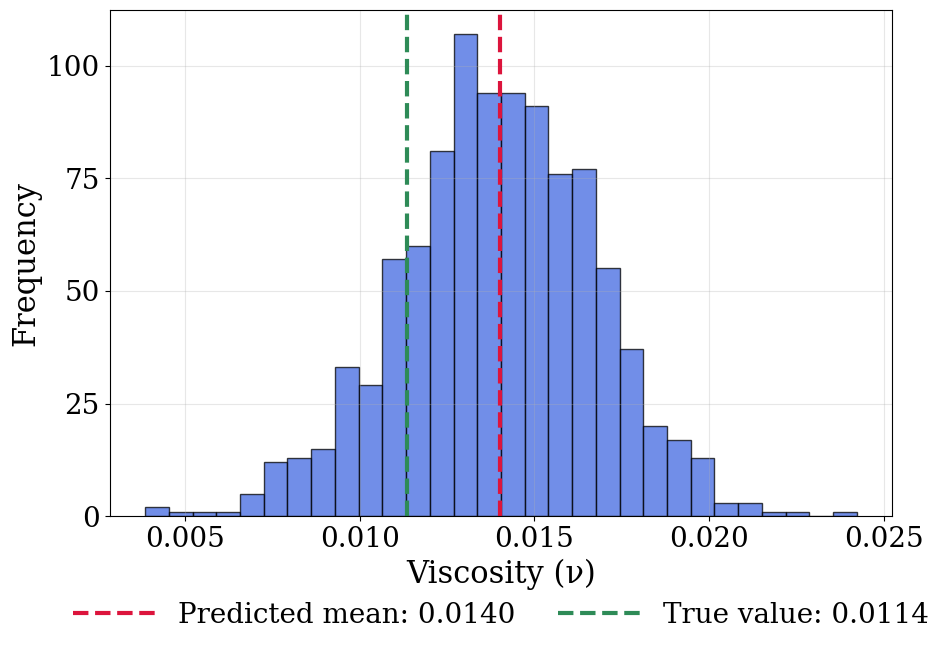

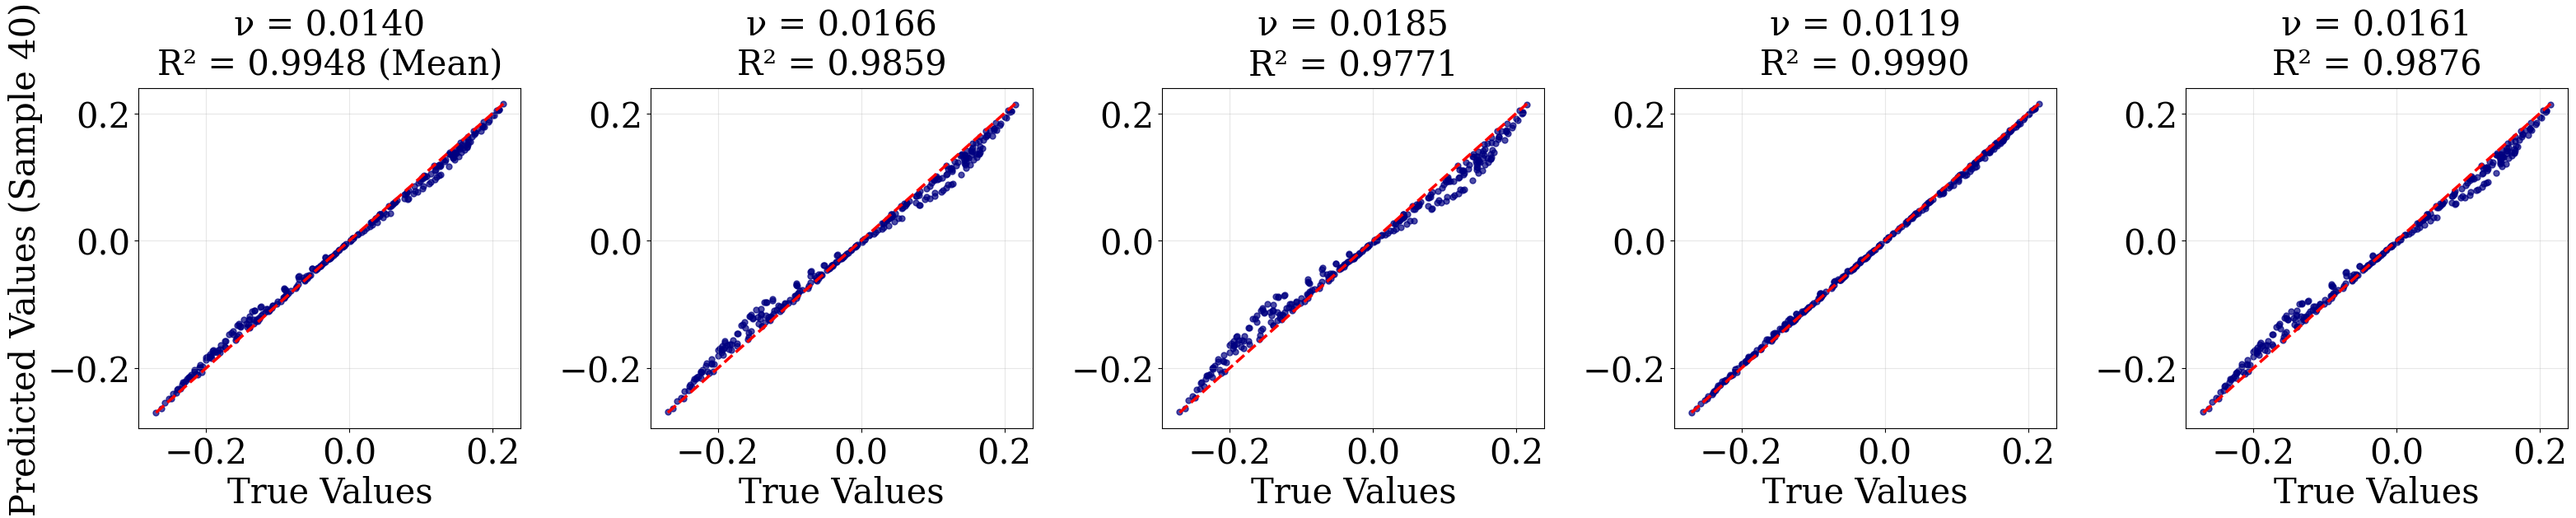

In [29]:

sample_num = sample 
# =============================================================================
#  1. Distribution of predicted ν (Histogram only)
# =============================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 22,
    "font.size": 22,
    "legend.fontsize": 18,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

plt.figure(figsize=(10, 7))
plt.hist(nu_samples_dist, bins=30, alpha=0.75, color="royalblue", edgecolor="black")

plt.axvline(float(np.array(nu_pred_mean)), color="crimson", linestyle="--",
            linewidth=3, label=f"Predicted mean: {float(np.array(nu_pred_mean)):.4f}")
plt.axvline(float(np.array(nu_test_true)), color="seagreen", linestyle="--",
            linewidth=3, label=f"True value: {float(np.array(nu_test_true)):.4f}")

plt.xlabel("Viscosity (ν)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

# Legend below the plot in two lines
plt.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=20,
    columnspacing=1.5,
    handlelength=3
)

# Limit ticks to 5 values
plt.locator_params(axis="x", nbins=5)
plt.locator_params(axis="y", nbins=5)

plt.tight_layout()
plt.savefig(f"predicted_nu_distribution_sample{sample_num}.png", dpi=600, bbox_inches="tight")
plt.savefig(f"predicted_nu_distribution_sample{sample_num}.pdf", dpi=600, bbox_inches="tight")
plt.show()


# =============================================================================
#  2. Prediction accuracy across ν values (5 panels)
# =============================================================================
plt.rcParams.update({
    "axes.labelsize": 30,
    "font.size": 30,
    "legend.fontsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
})

np.random.seed(0)
selected_indices = np.random.choice(len(nu_samples_dist), 4, replace=False)
nu_test_values = [float(np.array(nu_pred_mean))] + [nu_samples_dist[i] for i in selected_indices]

fig, axes = plt.subplots(1, 5, figsize=(32, 7))
axes = axes.flatten()

for i, nu_val in enumerate(nu_test_values):
    x_sol, sol_pred = burgers_solver(u0, nu_val, T=1.0, dt=1e-2, N=N)
    dsol_pred_loc, _, _ = extract_points(sol_pred.reshape(-1, 101, 101), p_data_train)
    dsol_pred_loc = dsol_pred_loc[0]

    ss_res = np.sum((u_data - dsol_pred_loc) ** 2)
    ss_tot = np.sum((u_data - np.mean(u_data)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)

    axes[i].scatter(u_data, dsol_pred_loc, s=25, alpha=0.7, color="navy")
    axes[i].plot([u_data.min(), u_data.max()],
                 [u_data.min(), u_data.max()],
                 "r--", linewidth=2.5)

    label = f"ν = {nu_val:.4f}\nR² = {r2_score:.4f}" + (" (Mean)" if i == 0 else "")
    axes[i].set_title(label, fontsize=30, pad=12)

    axes[i].set_xlabel("True Values")
    if i == 0:
        axes[i].set_ylabel(f"Predicted Values (Sample {sample_num})")
    else:
        axes[i].set_ylabel("")
    axes[i].grid(alpha=0.3)

plt.tight_layout()

# Save high-quality figures (PNG + PDF)
plt.savefig(f"prediction_accuracy_sample{sample_num}.png", dpi=600, bbox_inches="tight")
plt.savefig(f"prediction_accuracy_sample{sample_num}.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [37]:
import numpy as np
import pandas as pd

# Configuration
n_test_samples = 10       # Number of test samples to evaluate
n_nu_samples =  10        # Number of nu samples per test sample (v1, v2, v3, ...)
n_mc = 200               # Monte Carlo samples for nu distribution

# Storage for table
results = []

print("="*80)
print("GENERATING RESULTS TABLE")
print("="*80)

key = jax.random.PRNGKey(42)

# Helper function to subsample solver output to 101 time points
def run_solver_and_subsample(u0, nu_val, N=101, dt=1e-3):
    """Run Burgers solver and subsample to 101 time points"""
    x_sol, sol_pred_raw = burgers_solver(u0, nu_val, T=1.0, dt=dt, N=N)
    # Subsample to 101 time points
    step_size = max(1, sol_pred_raw.shape[0] // 101)
    sol_pred = sol_pred_raw[::step_size, :][:101, :]
    return sol_pred

for sample_idx in range(n_test_samples):
    print(f"\nProcessing Sample {sample_idx + 1}...")
    
    # Get true nu and initial condition
    nu_true = float(np.array(nu_test[sample_idx]))
    u0 = ic_and_nu_test[sample_idx, :-1]  # Initial condition
    u_data = data_output[sample_idx]       # Sensor measurements (input data)
    
    # =========================================================================
    # STEP 1: Run Burgers solver with TRUE ν to get REFERENCE solution
    # =========================================================================
    sol_true = run_solver_and_subsample(u0, nu_true, N=N)
    
    # Extract sensor values from reference solution
    dsol_true_loc, _, _ = extract_points(sol_true.reshape(-1, 101, 101), p_data_train)
    dsol_true_loc = dsol_true_loc[0]
    
    # R² for reference (should be ~1.0 if solver matches original data generation)
    ss_res_ref = np.sum((u_data - dsol_true_loc) ** 2)
    ss_tot_ref = np.sum((u_data - np.mean(u_data)) ** 2)
    r2_ref = 1 - (ss_res_ref / ss_tot_ref)
    
    # L₂ for reference (comparing with itself = 0)
    l2_ref = 0.0
    
    results.append({
        'Sample': sample_idx + 1,
        'v sampled': 'ν_true (ref)',
        'ν value': f'{nu_true:.6f}',
        'R² at sensors': f'{r2_ref:.4f}',
        'Full field L₂ error': f'{l2_ref:.4f}'
    })
    print(f"  ν_true (ref): ν={nu_true:.6f}, R²={r2_ref:.4f}, L₂={l2_ref:.4f}")
    
    # =========================================================================
    # STEP 2: Get network predictions for ν
    # =========================================================================
    nu_pred_all = apply_net_nu(model_fn_nu, params_nu, u_data)
    nu_pred_mean, nu_pred_logstd = nu_pred_all[0], nu_pred_all[1]
    nu_pred_mean = jax.nn.softplus(nu_pred_mean)
    nu_pred_std = jnp.exp(nu_pred_logstd)
    nu_pred_std = jnp.minimum(nu_pred_std, 0.2 * nu_pred_mean)
    
    # Generate MC samples for nu distribution
    nu_samples_list = []
    for i in range(n_mc):
        key, subkey = jax.random.split(key)
        eps = jax.random.normal(subkey, shape=nu_pred_mean.shape)
        nu_sampled = nu_pred_mean + eps * nu_pred_std
        nu_samples_list.append(float(np.array(nu_sampled)))
    
    # Select specific nu values to evaluate
    np.random.seed(sample_idx)
    selected_indices = np.random.choice(len(nu_samples_list), 
                                        min(n_nu_samples - 1, len(nu_samples_list)), 
                                        replace=False)
    nu_test_values = [float(np.array(nu_pred_mean))]  # v1 = mean
    for idx in selected_indices:
        nu_test_values.append(nu_samples_list[idx])
    
    # =========================================================================
    # STEP 3: Evaluate each sampled ν
    # =========================================================================
    for v_idx, nu_val in enumerate(nu_test_values):
        v_label = f'v_{v_idx + 1}' + (' (mean)' if v_idx == 0 else '')
        
        # Run Burgers solver with sampled ν
        sol_sampled = run_solver_and_subsample(u0, nu_val, N=N)
        
        # Extract sensor values from sampled solution
        dsol_sampled_loc, _, _ = extract_points(sol_sampled.reshape(-1, 101, 101), p_data_train)
        dsol_sampled_loc = dsol_sampled_loc[0]
        
        # R² at sensors: Does sampled ν solution match input sensor data?
        ss_res = np.sum((u_data - dsol_sampled_loc) ** 2)
        ss_tot = np.sum((u_data - np.mean(u_data)) ** 2)
        r2_sensors = 1 - (ss_res / ss_tot)
        
        # Full field L₂: How different is sampled solution from TRUE ν solution?
        l2_error_full = float(np.linalg.norm(sol_true - sol_sampled) / np.linalg.norm(sol_true))
            
        results.append({
            'Sample': sample_idx + 1,
            'v sampled': v_label,
            'ν value': f'{nu_val:.6f}',
            'R² at sensors': f'{r2_sensors:.4f}',
            'Full field L₂ error': f'{l2_error_full:.4f}'
        })
        
        print(f"  {v_label}: ν={nu_val:.6f}, R²={r2_sensors:.4f}, L₂={l2_error_full:.4f}")

# Create DataFrame
df_results = pd.DataFrame(results)

# Print table
print("\n" + "="*80)
print("RESULTS TABLE")
print("="*80)
print(df_results.to_string(index=False))

# Save to CSV
csv_path = "results_table.csv"
df_results.to_csv(csv_path, index=False)
print(f"\nTable saved to: {csv_path}")

# Also save as LaTeX table
latex_path = "results_table.tex"
with open(latex_path, 'w') as f:
    f.write(df_results.to_latex(index=False, escape=False))
print(f"LaTeX table saved to: {latex_path}")

# Print summary statistics (excluding reference rows)
print("\n" + "="*80)
print("SUMMARY STATISTICS (excluding reference)")
print("="*80)
non_ref_results = [r for r in results if 'ref' not in r['v sampled']]
r2_values = [float(r['R² at sensors']) for r in non_ref_results]
l2_values = [float(r['Full field L₂ error']) for r in non_ref_results]

print(f"R² at sensors:")
print(f"  Mean: {np.mean(r2_values):.4f}")
print(f"  Std:  {np.std(r2_values):.4f}")
print(f"  Min:  {np.min(r2_values):.4f}")
print(f"  Max:  {np.max(r2_values):.4f}")

print(f"\nFull field L₂ error:")
print(f"  Mean: {np.mean(l2_values):.4f}")
print(f"  Std:  {np.std(l2_values):.4f}")
print(f"  Min:  {np.min(l2_values):.4f}")
print(f"  Max:  {np.max(l2_values):.4f}")

# Analysis
print("\n" + "="*80)
print("ANALYSIS")
print("="*80)
print("Interpretation:")
print("  - High R², Low L₂ → Data matches AND full solution matches (good prediction)")
print("  - High R², High L₂ → Data matches BUT full solution differs (overfitting to sensors)")
print("  - Low R² → Data doesn't match (poor ν prediction)")


GENERATING RESULTS TABLE

Processing Sample 1...
  ν_true (ref): ν=0.039339, R²=0.9958, L₂=0.0000
  v_1 (mean): ν=0.016149, R²=0.7229, L₂=0.4171
  v_2: ν=0.015297, R²=0.6983, L₂=0.4376
  v_3: ν=0.022840, R²=0.8676, L₂=0.2712
  v_4: ν=0.017086, R²=0.7481, L₂=0.3951
  v_5: ν=0.010953, R²=0.5453, L₂=0.5500
  v_6: ν=0.021889, R²=0.8515, L₂=0.2904
  v_7: ν=0.015869, R²=0.7150, L₂=0.4238
  v_8: ν=0.007666, R²=0.3915, L₂=0.6451
  v_9: ν=0.016192, R²=0.7241, L₂=0.4160
  v_10: ν=0.015247, R²=0.6968, L₂=0.4388

Processing Sample 2...
  ν_true (ref): ν=0.019218, R²=0.9990, L₂=0.0000
  v_1 (mean): ν=0.014646, R²=0.9863, L₂=0.0853
  v_2: ν=0.017313, R²=0.9961, L₂=0.0339
  v_3: ν=0.015918, R²=0.9919, L₂=0.0602
  v_4: ν=0.016716, R²=0.9945, L₂=0.0450
  v_5: ν=0.020159, R²=0.9995, L₂=0.0160
  v_6: ν=0.012245, R²=0.9705, L₂=0.1364
  v_7: ν=0.016329, R²=0.9933, L₂=0.0523
  v_8: ν=0.021217, R²=0.9992, L₂=0.0333
  v_9: ν=0.010914, R²=0.9583, L₂=0.1671
  v_10: ν=0.010796, R²=0.9571, L₂=0.1699

Processing S